<a href="https://colab.research.google.com/github/Dxrksvng/eng-score-exit/blob/main/lastest_ktep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # SET UP

In [28]:
# --- ติดตั้ง Engine ของ Tesseract ---
!sudo apt install tesseract-ocr
!sudo apt install libtesseract-dev

# --- ติดตั้งไลบรารีที่จำเป็น (หากยังไม่ได้รัน) ---
!pip install pdf2image
!pip install poppler-utils
# ใช้ apt-get เพื่อติดตั้ง poppler-utils สำหรับระบบ (Debian/Ubuntu)
!sudo apt-get install -y poppler-utils

# --- ติดตั้ง Python Libraries ---
!pip install pytesseract
!pip install easyocr
!pip install transformers torch sentencepiece
!pip install pdf2image
!pip install poppler-utils # Dependency ของ pdf2image

!pip install openpyxl
!pip install jiwer

# --- 1. ติดตั้งไลบรารีที่จำเป็น ---
!pip install opencv-python-headless numpy matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libtesseract-dev is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.8).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Tran to image

In [30]:
import os
import cv2
import numpy as np
from pdf2image import convert_from_path

# --- 1. การตั้งค่า ---

# โฟลเดอร์ที่เก็บไฟล์ต้นทาง (PDF, JPG, etc.)
INPUT_DIR = '/content/drive/MyDrive/lastest-ktep/dataset'

# โฟลเดอร์สำหรับเก็บไฟล์ภาพ .png ที่แปลงเสร็จแล้ว
OUTPUT_DIR = '/content/drive/MyDrive/lastest-ktep/conv-to-img'

# --- 2. โค้ดหลักในการแปลงไฟล์ ---

def main():
    """
    ฟังก์ชันหลักที่จะวนลูปเพื่อแปลงไฟล์ทั้งหมด
    """
    # สร้างโฟลเดอร์ปลายทางหากยังไม่มี
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # ค้นหาไฟล์ทั้งหมดที่ต้องการแปลงในโฟลเดอร์ต้นทาง
    files_to_process = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.pdf', '.png', '.jpg', '.jpeg'))]

    if not files_to_process:
        print(f"ไม่พบไฟล์ที่สามารถแปลงได้ในโฟลเดอร์: {INPUT_DIR}")
        return

    print(f"พบไฟล์ทั้งหมด {len(files_to_process)} ไฟล์ เริ่มดำเนินการแปลง...")

    # วนลูปทำงานทีละไฟล์
    for filename in files_to_process:
        try:
            filepath = os.path.join(INPUT_DIR, filename)

            # --- ส่วนของการแปลงไฟล์ ---
            if filename.lower().endswith('.pdf'):
                # ถ้าเป็น PDF ให้ใช้ pdf2image แปลงหน้าแรก
                images = convert_from_path(filepath)
                bgr_image = np.array(images[0])
                bgr_image = cv2.cvtColor(bgr_image, cv2.COLOR_RGB2BGR)
            else:
                # ถ้าเป็นไฟล์ภาพอยู่แล้ว ให้ใช้ OpenCV อ่านเข้ามาโดยตรง
                bgr_image = cv2.imread(filepath)

            # ตรวจสอบว่าโหลดภาพสำเร็จหรือไม่
            if bgr_image is None:
                print(f"  -> ไม่สามารถอ่านไฟล์: {filename}, ขอข้ามไฟล์นี้")
                continue

            # --- ส่วนของการบันทึกไฟล์ ---
            # สร้างชื่อไฟล์ใหม่ให้เป็น .png เสมอ
            new_filename = f"{os.path.splitext(filename)[0]}.png"
            save_path = os.path.join(OUTPUT_DIR, new_filename)

            # บันทึกไฟล์ภาพ
            cv2.imwrite(save_path, bgr_image)

            print(f"  -> แปลงไฟล์ '{filename}' เป็น '{new_filename}' เรียบร้อยแล้ว")

        except Exception as e:
            print(f"  !!!! เกิดข้อผิดพลาดกับไฟล์ {filename}: {e}")

    print("-" * 50)
    print("การแปลงไฟล์ทั้งหมดเสร็จสิ้น!")
    print(f"ไฟล์ภาพ .png ทั้งหมดถูกบันทึกไว้ที่: {OUTPUT_DIR}")


# สั่งให้โปรแกรมเริ่มทำงานเมื่อรันไฟล์นี้
if __name__ == "__main__":
    main()

พบไฟล์ทั้งหมด 120 ไฟล์ เริ่มดำเนินการแปลง...
  -> แปลงไฟล์ 'KMITL-TEP PILOT-2.pdf' เป็น 'KMITL-TEP PILOT-2.png' เรียบร้อยแล้ว
  -> แปลงไฟล์ 'KMITL-TEP PILOT-1.pdf' เป็น 'KMITL-TEP PILOT-1.png' เรียบร้อยแล้ว
  -> แปลงไฟล์ 'KMITL-TEP PILOT-3.pdf' เป็น 'KMITL-TEP PILOT-3.png' เรียบร้อยแล้ว
  -> แปลงไฟล์ 'KMITL-TEP PILOT-4.pdf' เป็น 'KMITL-TEP PILOT-4.png' เรียบร้อยแล้ว
  -> แปลงไฟล์ 'KMITL-TEP PILOT-5.pdf' เป็น 'KMITL-TEP PILOT-5.png' เรียบร้อยแล้ว
  -> แปลงไฟล์ 'KMITL-TEP PILOT-6.pdf' เป็น 'KMITL-TEP PILOT-6.png' เรียบร้อยแล้ว
  -> แปลงไฟล์ 'KMITL-TEP PILOT-7.pdf' เป็น 'KMITL-TEP PILOT-7.png' เรียบร้อยแล้ว
  -> แปลงไฟล์ 'KMITL-TEP PILOT-8.pdf' เป็น 'KMITL-TEP PILOT-8.png' เรียบร้อยแล้ว
  -> แปลงไฟล์ 'KMITL-TEP PILOT-9.pdf' เป็น 'KMITL-TEP PILOT-9.png' เรียบร้อยแล้ว
  -> แปลงไฟล์ 'KMITL-TEP PILOT-10.pdf' เป็น 'KMITL-TEP PILOT-10.png' เรียบร้อยแล้ว
  -> แปลงไฟล์ 'KMITL-TEP PILOT-11.pdf' เป็น 'KMITL-TEP PILOT-11.png' เรียบร้อยแล้ว
  -> แปลงไฟล์ 'KMITL-TEP PILOT-12.pdf' เป็น 'KMITL-TEP PILOT

In [31]:
import os
from pdf2image import convert_from_path
from tqdm import tqdm # เพิ่ม tqdm เพื่อให้เห็น progress bar สวยๆ

# --- 1. ตั้งค่า Path ของโฟลเดอร์ ---
# !!! ให้แก้เป็น path ใน Google Drive ของคุณ !!!
PDF_FOLDER = '/content/drive/MyDrive/lastest-ktep/dataset/'
IMAGE_FOLDER = '/content/drive/MyDrive/lastest-ktep/output_images/'

# --- 2. สร้างโฟลเดอร์สำหรับเก็บภาพ (หากยังไม่มี) ---
os.makedirs(IMAGE_FOLDER, exist_ok=True)
print(f"ไฟล์รูปภาพจะถูกบันทึกไว้ที่: {IMAGE_FOLDER}")

# --- 3. ดึงรายชื่อไฟล์ PDF ทั้งหมด ---
try:
    # กรองเอาเฉพาะไฟล์ที่ลงท้ายด้วย .pdf หรือ .PDF
    pdf_files = [f for f in os.listdir(PDF_FOLDER) if f.lower().endswith('.pdf')]
    if not pdf_files:
        print(f"ไม่พบไฟล์ PDF ในโฟลเดอร์: {PDF_FOLDER}")
    else:
        print(f"พบไฟล์ PDF ทั้งหมด {len(pdf_files)} ไฟล์ กำลังเริ่มทำการแปลง...")

        # --- 4. วนลูปเพื่อแปลงไฟล์ทั้งหมด ---
        for pdf_file in tqdm(pdf_files, desc="Converting PDFs to Images"):
            pdf_path = os.path.join(PDF_FOLDER, pdf_file)

            # ตั้งชื่อไฟล์ output ให้เหมือนไฟล์ input แต่เปลี่ยนนามสกุลเป็น .png
            output_filename = f"{os.path.splitext(pdf_file)[0]}.png"
            image_path = os.path.join(IMAGE_FOLDER, output_filename)

            # ตรวจสอบว่าไฟล์ภาพนี้เคยถูกสร้างไว้แล้วหรือยัง เพื่อจะได้ไม่ต้องทำซ้ำ
            if os.path.exists(image_path):
                # print(f"ข้ามไฟล์ {pdf_file} เนื่องจากมีไฟล์ภาพอยู่แล้ว")
                continue

            try:
                # แปลงไฟล์ PDF เป็นภาพ (เราเอาเฉพาะหน้าแรก)
                images = convert_from_path(pdf_path, dpi=300)
                if images:
                    images[0].save(image_path, 'PNG')
            except Exception as e:
                print(f"เกิดข้อผิดพลาดระหว่างแปลงไฟล์ {pdf_file}: {e}")

        print("\nการแปลงไฟล์ทั้งหมดเสร็จสมบูรณ์!")

except FileNotFoundError:
    print(f"ไม่พบโฟลเดอร์ต้นทาง: {PDF_FOLDER}")
    print("โปรดตรวจสอบว่า Path ถูกต้อง และคุณได้ Mount Google Drive แล้ว")

ไฟล์รูปภาพจะถูกบันทึกไว้ที่: /content/drive/MyDrive/lastest-ktep/output_images/
พบไฟล์ PDF ทั้งหมด 120 ไฟล์ กำลังเริ่มทำการแปลง...


Converting PDFs to Images: 100%|██████████| 120/120 [02:47<00:00,  1.39s/it]


การแปลงไฟล์ทั้งหมดเสร็จสมบูรณ์!


# Preproceess image

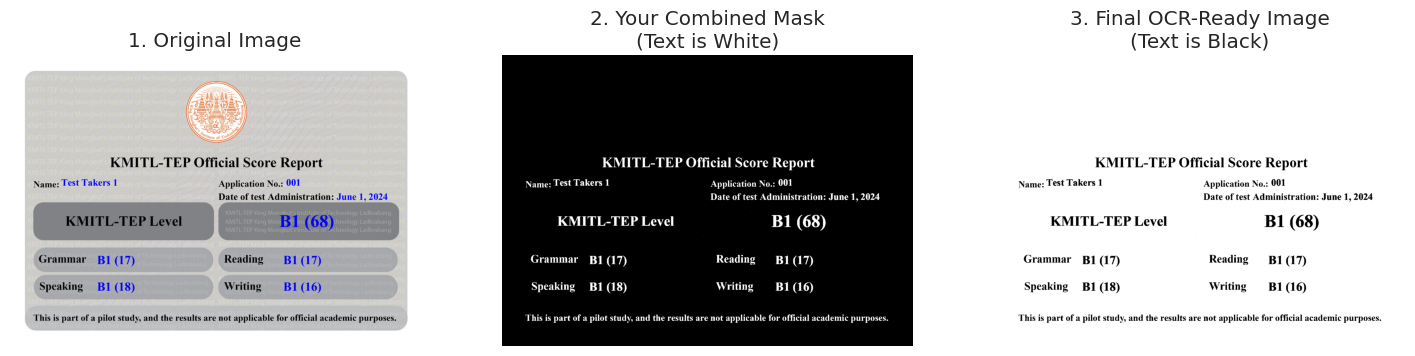

บันทึกภาพที่พร้อมสำหรับ OCR แล้วที่: ocr_ready_output.png


In [32]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from PIL import Image
import matplotlib.pyplot as plt

# --- 1. โหลดรูปภาพ ---
# !!! แก้ไข Path ให้ถูกต้อง !!!
IMAGE_PATH = '/content/drive/MyDrive/lastest-ktep/conv-to-img/KMITL-TEP PILOT-1.png'
image = cv2.imread(IMAGE_PATH)

# --- 2. สร้าง MASK จากสี (โค้ดส่วนใหญ่ของคุณ) ---
# แปลงภาพเป็น HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# กำหนดช่วงสีดำ (ปรับค่า upper_black เล็กน้อยเพื่อความแม่นยำ)
lower_black = np.array([0, 0, 0])
upper_black = np.array([180, 255, 120]) # เพิ่มช่วง Hue และ Saturation, ลด Value

# กำหนดช่วงสีน้ำเงิน
lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])

# สร้าง Mask สำหรับแต่ละสี
mask_black = cv2.inRange(hsv, lower_black, upper_black)
mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

# รวม Mask ทั้งสองเข้าด้วยกัน
# สิ่งใดที่เป็นสีดำหรือสีน้ำเงิน จะกลายเป็นสีขาว (ค่า 255) ใน combined_mask
combined_mask = cv2.bitwise_or(mask_black, mask_blue)


# --- 3. ขั้นตอนสำคัญ: เปลี่ยน MASK ให้เป็นภาพสำหรับ OCR ---
# ใน combined_mask ตอนนี้ ตัวอักษรเป็นสีขาว พื้นหลังเป็นสีดำ
# OCR ต้องการให้ตัวอักษรเป็นสีดำ และพื้นหลังเป็นสีขาว เราจึงต้อง "สลับสี" (Invert)
# cv2.bitwise_not จะเปลี่ยนขาวเป็นดำ และดำเป็นขาว
final_binary_image = cv2.bitwise_not(combined_mask)


# --- 4. แสดงผลลัพธ์เพื่อเปรียบเทียบ ---
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('1. Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(combined_mask, cmap='gray')
plt.title('2. Your Combined Mask\n(Text is White)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(final_binary_image, cmap='gray')
plt.title('3. Final OCR-Ready Image\n(Text is Black)')
plt.axis('off')

plt.show()

# บันทึกภาพผลลัพธ์สุดท้าย
output_path = 'ocr_ready_output.png'
cv2.imwrite(output_path, final_binary_image)
print(f"บันทึกภาพที่พร้อมสำหรับ OCR แล้วที่: {output_path}")

<ipython-input-33-1689392346>:48: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-33-1689392346>:48: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-33-1689392346>:48: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-33-1689392346>:48: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-33-1689392346>:48: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-33-1689392346>:48: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-33-1689392346>:48: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-i

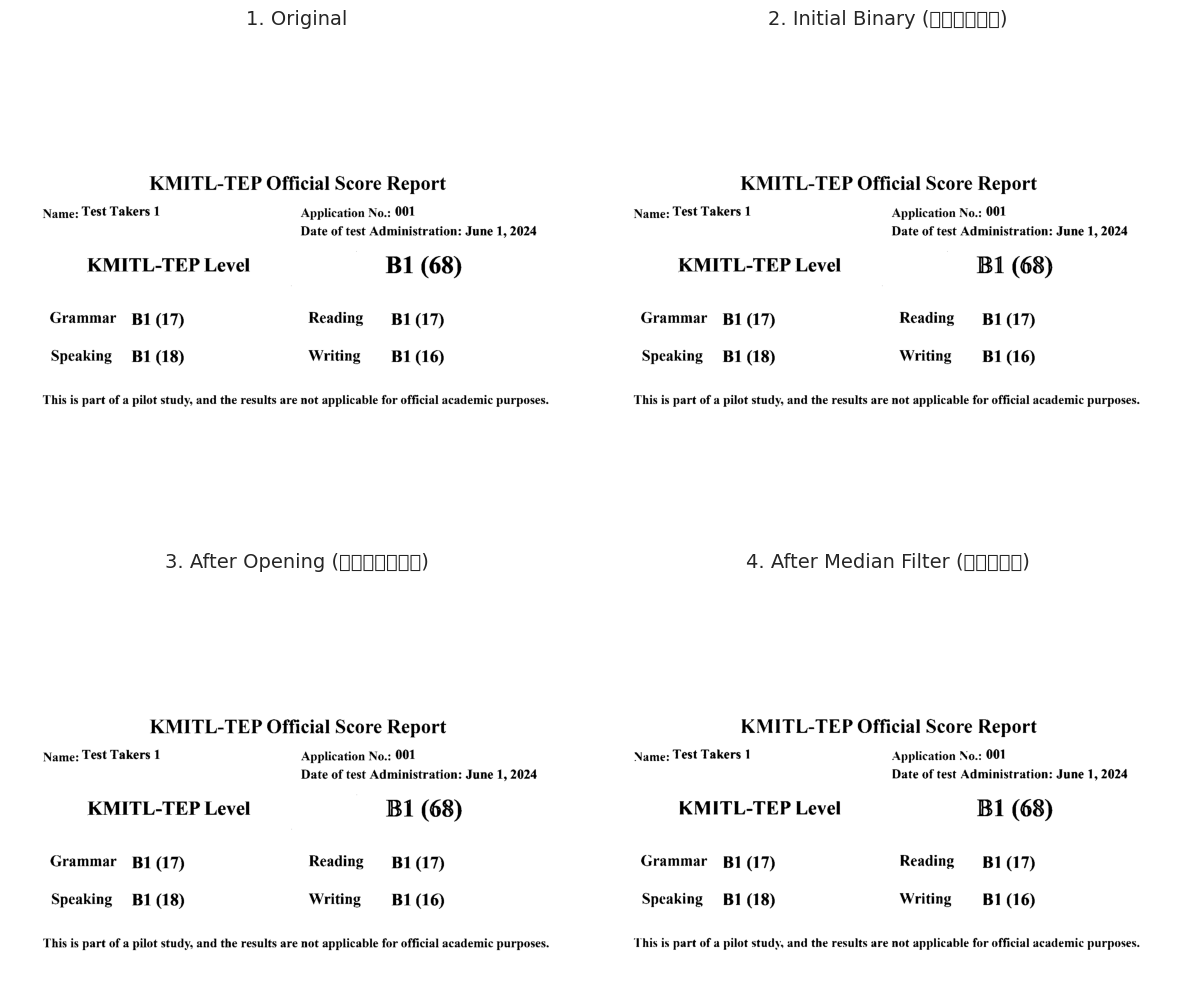

In [33]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# --- 1. กำหนด Path ของรูปภาพสีต้นฉบับ ---
ORIGINAL_IMAGE_PATH = "/content/drive/MyDrive/lastest-ktep/prep-img/KMITL-TEP PILOT-1.png" # <<< แก้ไข Path ของภาพ IT-SS-001

# --- 2. ฟังก์ชัน Preprocessing และ Cleaning ---
def create_and_clean_image(image_path):
    # อ่านภาพสี
    image = cv2.imread(image_path)
    if image is None: return None

    # 1. ทำ Preprocessing พื้นฐาน (Grayscale + Adaptive Thresholding)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    initial_binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

    # 2. ทำความสะอาดด้วย Opening
    # kernel คือขนาดของ "แปรง" ที่เราจะใช้ขัด (ขนาดเล็กๆ เช่น 2x2 หรือ 3x3 กำลังดี)
    kernel = np.ones((2, 2), np.uint8)
    opened_image = cv2.morphologyEx(initial_binary, cv2.MORPH_OPEN, kernel, iterations=1)

    # 3. ทำความสะอาดด้วย Median Filter
    # ksize=3 คือดูพิกเซลรอบๆ 3x3 เพื่อหาค่ากลาง
    median_filtered_image = cv2.medianBlur(initial_binary, 3)

    return image, initial_binary, opened_image, median_filtered_image

# --- 3. เริ่มกระบวนการและแสดงผลเปรียบเทียบ ---
try:
    original, binary, opened, median = create_and_clean_image(ORIGINAL_IMAGE_PATH)

    # --- 4. แสดงผลลัพธ์ทุกขั้นตอน ---
    images_to_display = {
        "1. Original": cv2.cvtColor(original, cv2.COLOR_BGR2RGB),
        "2. Initial Binary (มีติ่ง)": binary,
        "3. After Opening (ขัดติ่ง)": opened,
        "4. After Median Filter (ลบจุด)": median
    }

    plt.figure(figsize=(12, 12))
    for i, (title, image) in enumerate(images_to_display.items()):
        plt.subplot(2, 2, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(title, fontsize=14)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

**AUTO Black-white**

In [34]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# --- 1. ตั้งค่า Path ของโฟลเดอร์ ---
# !!! ให้แก้เป็น path ใน Google Drive ของคุณ !!!

# โฟลเดอร์ที่เก็บภาพสีต้นฉบับ (ที่แปลงจาก PDF)
INPUT_IMAGE_FOLDER = '/content/drive/MyDrive/lastest-ktep/conv-to-img'

# โฟลเดอร์ที่จะใช้เก็บภาพขาวดำที่ผ่าน Preprocessing แล้ว
OUTPUT_PROCESSED_FOLDER = '/content/drive/MyDrive/lastest-ktep/prep-img/'

# --- 2. สร้างโฟลเดอร์สำหรับเก็บผลลัพธ์ (หากยังไม่มี) ---
os.makedirs(OUTPUT_PROCESSED_FOLDER, exist_ok=True)
print(f"รูปภาพที่ประมวลผลแล้วจะถูกบันทึกที่: {OUTPUT_PROCESSED_FOLDER}")


# --- 3. ฟังก์ชัน Preprocessing ที่ดีที่สุดของเรา ---
def create_ocr_ready_image(image_path):
    """
    อ่านภาพสี, ใช้ HSV Mask เพื่อแยกตัวอักษร, และแปลงเป็นภาพขาวดำ
    """
    image = cv2.imread(image_path)
    if image is None:
        return None # กรณีอ่านไฟล์ภาพไม่ได้

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # กำหนดช่วงสีดำและน้ำเงิน
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([180, 255, 120])
    lower_blue = np.array([90, 50, 50])
    upper_blue = np.array([130, 255, 255])

    # สร้างและรวม Mask
    mask_black = cv2.inRange(hsv, lower_black, upper_black)
    mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)
    combined_mask = cv2.bitwise_or(mask_black, mask_blue)

    # สลับสี (Invert) เพื่อให้ตัวอักษรเป็นสีดำ พื้นหลังเป็นสีขาว
    final_binary_image = cv2.bitwise_not(combined_mask)

    return final_binary_image


# --- 4. เริ่มกระบวนการ xử lý ทั้งหมดในโฟลเดอร์ ---
try:
    # กรองเอารายชื่อไฟล์รูปภาพ
    image_files = [f for f in os.listdir(INPUT_IMAGE_FOLDER) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"พบรูปภาพทั้งหมด {len(image_files)} รูป, กำลังเริ่มประมวลผล...")

    # วนลูปเพื่อประมวลผลทีละไฟล์
    for filename in tqdm(image_files, desc="Processing Images"):
        input_path = os.path.join(INPUT_IMAGE_FOLDER, filename)
        output_path = os.path.join(OUTPUT_PROCESSED_FOLDER, filename)

        # ข้ามไฟล์ที่เคยทำไปแล้ว
        if os.path.exists(output_path):
            continue

        try:
            # ประมวลผลภาพ
            ocr_ready_image = create_ocr_ready_image(input_path)
            if ocr_ready_image is not None:
                # บันทึกผลลัพธ์
                cv2.imwrite(output_path, ocr_ready_image)
        except Exception as e:
            print(f"\nเกิดข้อผิดพลาดระหว่างประมวลผลไฟล์ {filename}: {e}")

    print("\nประมวลผลรูปภาพทั้งหมดเสร็จสมบูรณ์!")

except FileNotFoundError:
    print(f"\nERROR: ไม่พบโฟลเดอร์ {INPUT_IMAGE_FOLDER}. กรุณาตรวจสอบ Path อีกครั้ง")

รูปภาพที่ประมวลผลแล้วจะถูกบันทึกที่: /content/drive/MyDrive/lastest-ktep/prep-img/
พบรูปภาพทั้งหมด 120 รูป, กำลังเริ่มประมวลผล...


Processing Images: 100%|██████████| 120/120 [00:00<00:00, 7562.87it/s]


ประมวลผลรูปภาพทั้งหมดเสร็จสมบูรณ์!


In [35]:
import cv2
import numpy as np
import os
from tqdm import tqdm

# --- 1. กำหนด Path ที่สำคัญ ---
# !!! กรุณาแก้ไข Path ให้ถูกต้องตามตำแหน่งใน Drive ของคุณ !!!

# โฟลเดอร์ที่เก็บ "รูปสีต้นฉบับ"
INPUT_COLOR_IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/prep-img" # <<< แก้ไขเป็น Path รูปสีของคุณ

# โฟลเดอร์ที่จะใช้เก็บ "รูปขาวดำที่สะอาดแล้ว"
OUTPUT_CLEANED_IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/prep-img-Artifacts"


# --- 2. สร้างโฟลเดอร์สำหรับเก็บผลลัพธ์ (หากยังไม่มี) ---
os.makedirs(OUTPUT_CLEANED_IMAGE_DIR, exist_ok=True)
print(f"รูปภาพที่ประมวลผลแล้วจะถูกบันทึกที่: {OUTPUT_CLEANED_IMAGE_DIR}")


# --- 3. ฟังก์ชันสำหรับ Preprocessing และ Cleaning ที่ดีที่สุด ---
def create_final_cleaned_image(image_path):
    """
    รวมทุกขั้นตอนที่ดีที่สุด: Grayscale -> Adaptive Thresholding -> Opening
    """
    # อ่านภาพสี
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: ไม่สามารถอ่านไฟล์ภาพ {os.path.basename(image_path)}")
        return None

    # 1. แปลงเป็นภาพ Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 2. ทำ Adaptive Thresholding
    initial_binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

    # 3. ทำความสะอาดด้วย Opening เพื่อขจัด 'ติ่ง' และ Noise
    kernel = np.ones((2, 2), np.uint8)
    cleaned_image = cv2.morphologyEx(initial_binary, cv2.MORPH_OPEN, kernel, iterations=1)

    return cleaned_image


# --- 4. เริ่มกระบวนการประมวลผลทั้งหมดในโฟลเดอร์ ---
try:
    image_files = [f for f in os.listdir(INPUT_COLOR_IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"พบรูปภาพทั้งหมด {len(image_files)} รูป, กำลังเริ่มประมวลผล...")

    # วนลูปเพื่อประมวลผลทีละไฟล์
    for filename in tqdm(image_files, desc="Cleaning Images"):
        input_path = os.path.join(INPUT_COLOR_IMAGE_DIR, filename)
        output_path = os.path.join(OUTPUT_CLEANED_IMAGE_DIR, filename)

        # ข้ามไฟล์ที่เคยทำไปแล้วเพื่อความรวดเร็ว
        if os.path.exists(output_path):
            continue

        try:
            # ประมวลผลภาพ
            final_image = create_final_cleaned_image(input_path)

            # บันทึกผลลัพธ์
            if final_image is not None:
                cv2.imwrite(output_path, final_image)
        except Exception as e:
            print(f"\nเกิดข้อผิดพลาดระหว่างประมวลผลไฟล์ {filename}: {e}")

    print("\n--- ✅ ประมวลผลรูปภาพทั้งหมดเสร็จสมบูรณ์! ---")

except FileNotFoundError:
    print(f"\n[ERROR] ไม่พบโฟลเดอร์ต้นทาง: {INPUT_COLOR_IMAGE_DIR}")
    print("โปรดตรวจสอบว่า Path ถูกต้อง และชี้ไปยังโฟลเดอร์ที่เก็บ 'รูปสีต้นฉบับ'")

รูปภาพที่ประมวลผลแล้วจะถูกบันทึกที่: /content/drive/MyDrive/lastest-ktep/prep-img-Artifacts
พบรูปภาพทั้งหมด 120 รูป, กำลังเริ่มประมวลผล...


Cleaning Images: 100%|██████████| 120/120 [00:04<00:00, 24.06it/s]


--- ✅ ประมวลผลรูปภาพทั้งหมดเสร็จสมบูรณ์! ---


# pytesseract


In [36]:
import pytesseract
from PIL import Image

# --- 1. กำหนดค่าและ Path ---
# ระบุ Path ของภาพที่ผ่าน Preprocess แล้ว (ไฟล์ขาวดำ)
# ผมจะอิงจาก Path ที่คุณเคยใช้ล่าสุด และเลือกไฟล์ภาพที่ 1 มาทดสอบ
IMAGE_PATH = "/content/drive/MyDrive/lastest-ktep/prep-img/KMITL-TEP PILOT-1.png"

# --- 2. เริ่มกระบวนการสกัดข้อความดิบ ---
try:
    print(f"--- 🚀 กำลังอ่านข้อความจากรูปภาพ: {IMAGE_PATH} ---")

    # ใช้ Tesseract อ่านทั้งหน้า
    # Page Segmentation Mode (psm) 4: จะพยายามมองหาข้อความที่เป็นคอลัมน์เดียว
    config = r'--oem 3 --psm 4'

    # สกัดข้อความดิบ
    raw_text = pytesseract.image_to_string(IMAGE_PATH, config=config)

    # --- 3. แสดงผลลัพธ์ ---
    print("\n" + "="*50)
    print("📄 RAW TEXT OUTPUT FROM TESSERACT (PURE OCR) 📄")
    print("="*50)
    # พิมพ์ผลลัพธ์ที่ได้ออกมาทั้งหมด
    print(raw_text)
    print("="*50)
    print("\n--- ✅ เสร็จสิ้น ---")
    print("โปรดตรวจสอบข้อความด้านบนเพื่อหา Pattern สำหรับขั้นตอนถัดไป")

except FileNotFoundError:
    print(f"\n[ERROR] ไม่พบไฟล์ที่ Path: {IMAGE_PATH}")
    print("กรุณาตรวจสอบว่า Path ของไฟล์ถูกต้องหรือไม่")
except Exception as e:
    print(f"\nAn error occurred: {e}")

--- 🚀 กำลังอ่านข้อความจากรูปภาพ: /content/drive/MyDrive/lastest-ktep/prep-img/KMITL-TEP PILOT-1.png ---

📄 RAW TEXT OUTPUT FROM TESSERACT (PURE OCR) 📄
KMITL-TEP Official Score Report

Name: Test Takers 1 Application No.: 001
Date of test Administration: June 1, 2024
KMITL-TEP Level B1 (68)
Grammar BI (17) Reading B1(17)
Speaking B1 (18) Writing ~=— B11 (16)

This is part of a pilot study, and the results are not applicable for official academic purposes.


--- ✅ เสร็จสิ้น ---
โปรดตรวจสอบข้อความด้านบนเพื่อหา Pattern สำหรับขั้นตอนถัดไป


In [37]:
import cv2
import pandas as pd
import re
import pytesseract
from PIL import Image
from IPython.display import display

# --- 1. กำหนดค่าและ Path ---
ORIGINAL_IMAGE_PATH = "/content/drive/MyDrive/lastest-ktep/prep-img/KMITL-TEP PILOT-1.png"
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"
TARGET_ID = 1

# --- 2. Parser ฉบับสมบูรณ์ที่สุด ---
def final_parser(full_text):
    data = {}

    def clean_level(level_text):
        if not level_text: return None
        cleaned = level_text.upper().replace('I', '1').replace('l', '1')
        if 'B11' in cleaned: return 'B1'
        return cleaned

    def parse_score(text):
        if not text: return None, None
        match = re.search(r"([A-Z1-9]+)\s*\(\s*(\d+)\)", text)
        return (clean_level(match.group(1)), match.group(2)) if match else (None, None)

    # Header
    name_match = re.search(r"Name\s*:?\s*(.*?)\s*(?:Application No|Date of test)", full_text, re.DOTALL | re.IGNORECASE)
    data['name'] = re.sub(r'\s+', ' ', name_match.group(1).strip()) if name_match else None
    app_no_match = re.search(r"Application No\.?\s*:*\s*([A-Z0-9\-]+)", full_text, re.IGNORECASE)
    data['application_no'] = app_no_match.group(1).strip() if app_no_match else None

    # ⬇️⬇️⬇️ แก้ไข Regex ของ Test Date ที่นี่ ⬇️⬇️⬇️
    date_match = re.search(r"Administration\s*:?\s*([A-Za-z]+\s+\d{1,2},\s+\d{4})", full_text, re.IGNORECASE)
    data['test_date'] = date_match.group(1).strip() if date_match else None

    # Scores
    total_block = re.search(r"KMITL-TEP Level(.*)", full_text, re.DOTALL | re.IGNORECASE)
    data['total_level'], data['total_score'] = parse_score(total_block.group(1) if total_block else "")
    grammar_block = re.search(r"Grammar(.*?)Reading", full_text, re.DOTALL | re.IGNORECASE)
    data['grammar_level'], data['grammar_score'] = parse_score(grammar_block.group(1) if grammar_block else "")
    reading_block = re.search(r"Reading(.*?)Speaking", full_text, re.DOTALL | re.IGNORECASE)
    data['reading_level'], data['reading_score'] = parse_score(reading_block.group(1) if reading_block else "")
    speaking_block = re.search(r"Speaking(.*?)Writing", full_text, re.DOTALL | re.IGNORECASE)
    data['speaking_level'], data['speaking_score'] = parse_score(speaking_block.group(1) if speaking_block else "")
    writing_block = re.search(r"Writing(.*)", full_text, re.DOTALL | re.IGNORECASE)
    data['writing_level'], data['writing_score'] = parse_score(writing_block.group(1) if writing_block else "")

    return data

# --- 3. ฟังก์ชัน Preprocessing ---
def create_ocr_ready_image(image_path):
    image = cv2.imread(image_path)
    if image is None: return None
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    binary_image = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    return binary_image

# --- 4. เริ่มกระบวนการทั้งหมด ---
try:
    # โหลด Ground Truth
    gt_df = pd.read_excel(GROUND_TRUTH_PATH)
    target_gt_row = gt_df[gt_df['No.'] == TARGET_ID].iloc[0]

    # ประมวลผลและสกัดข้อมูล
    processed_image = create_ocr_ready_image(ORIGINAL_IMAGE_PATH)
    full_text = pytesseract.image_to_string(processed_image, config=r'--oem 3 --psm 3')
    extracted_data = final_parser(full_text)

    # สร้างตารางเปรียบเทียบ
    comparison_data = [
        {'Field': 'Name', 'Ground Truth': target_gt_row['Name'], 'Prediction': extracted_data.get('name')},
        {'Field': 'Application No.', 'Ground Truth': target_gt_row['Application No.'], 'Prediction': extracted_data.get('application_no')},
        {'Field': 'Test Date', 'Ground Truth': target_gt_row['Test Date'], 'Prediction': extracted_data.get('test_date')},
        {'Field': 'Grammar Level', 'Ground Truth': target_gt_row['Grammar_Level'], 'Prediction': extracted_data.get('grammar_level')},
        {'Field': 'Grammar Score', 'Ground Truth': target_gt_row['Grammar_Score'], 'Prediction': extracted_data.get('grammar_score')},
        {'Field': 'Reading Level', 'Ground Truth': target_gt_row['Reading_Level'], 'Prediction': extracted_data.get('reading_level')},
        {'Field': 'Reading Score', 'Ground Truth': target_gt_row['Reading_Score'], 'Prediction': extracted_data.get('reading_score')},
        {'Field': 'Speaking Level', 'Ground Truth': target_gt_row['Speaking_Level'], 'Prediction': extracted_data.get('speaking_level')},
        {'Field': 'Speaking Score', 'Ground Truth': target_gt_row['Speaking_Score'], 'Prediction': extracted_data.get('speaking_score')},
        {'Field': 'Writing Level', 'Ground Truth': target_gt_row['Writing_Level'], 'Prediction': extracted_data.get('writing_level')},
        {'Field': 'Writing Score', 'Ground Truth': target_gt_row['Writing_Score'], 'Prediction': extracted_data.get('writing_score')},
        {'Field': 'Total Level', 'Ground Truth': target_gt_row['Total_Level'], 'Prediction': extracted_data.get('total_level')},
        {'Field': 'Total Score', 'Ground Truth': target_gt_row['Total_Score'], 'Prediction': extracted_data.get('total_score')},
    ]
    comparison_df = pd.DataFrame(comparison_data)

    # แสดงผลลัพธ์
    print("\n--- ✅ Final Result: Tesseract (Pure OCR) vs Ground Truth (Corrected) ---")
    display(comparison_df)

except Exception as e:
    print(f"\nAn error occurred: {e}")


--- ✅ Final Result: Tesseract (Pure OCR) vs Ground Truth (Corrected) ---


,Field,Ground Truth,Prediction
0,Name,Test Takers 1,Test Takers 1
1,Application No.,1,001
2,Test Date,"June 1, 2024","June 1, 2024"
3,Grammar Level,B1,B1
4,Grammar Score,17,17
5,Reading Level,B1,B1
6,Reading Score,17,17
7,Speaking Level,B1,B1
8,Speaking Score,18,18
9,Writing Level,B1,B1


In [38]:
import cv2
import pandas as pd
import os
import re
import jiwer
import numpy as np
import pytesseract
from tqdm import tqdm

# --- 1. กำหนดค่าและ Path ---
MODEL_NAME = 'Tesseract'
APPROACH_NAME = 'Pure OCR'
MASTER_OUTPUT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
INDIVIDUAL_REPORT_PATH = f"/content/drive/MyDrive/lastest-ktep/excel/{MODEL_NAME.lower()}_{APPROACH_NAME.replace(' ', '_').lower()}_report.xlsx"
IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/prep-img"
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"

# --- 2. ฟังก์ชันช่วยเหลือ ---
# (ไม่มีการเปลี่ยนแปลงในส่วนฟังก์ชัน)
def get_id_from_filename(filename):
    match = re.search(r'(\d+)\.(png|jpg|jpeg)$', filename.lower())
    if match: return int(match.group(1))
    return None

def normalize_text(text):
    if text is None: return ""
    text_str = str(text).strip().lower().replace(' ', '')
    if text_str.endswith('.0'): text_str = text_str[:-2]
    return text_str

def final_robust_parser(full_text):
    data = {}
    def clean_level(level_text):
        if not level_text: return None
        cleaned = level_text.upper().replace('I', '1').replace('l', '1')
        if 'B11' in cleaned: return 'B1'
        return cleaned
    def parse_score(text):
        if not text: return None, None
        match = re.search(r"([A-Z1-9]+)\s*\(\s*(\d+)\)", text)
        return (clean_level(match.group(1)), match.group(2)) if match else (None, None)
    name_match = re.search(r"Name\s*:?\s*(.*?)\s*(?:Application No|Date of test)", full_text, re.DOTALL | re.IGNORECASE)
    data['name'] = re.sub(r'\s+', ' ', name_match.group(1).strip()) if name_match else None
    app_no_match = re.search(r"Application No\.?\s*:*\s*([A-Z0-9\-]+)", full_text, re.IGNORECASE)
    data['application_no'] = app_no_match.group(1).strip() if app_no_match else None
    date_match = re.search(r"Administration\s*:?\s*([A-Za-z]+\s+\d{1,2},\s+\d{4})", full_text, re.IGNORECASE)
    data['test_date'] = date_match.group(1).strip() if date_match else None
    total_block = re.search(r"KMITL-TEP Level(.*)", full_text, re.DOTALL | re.IGNORECASE)
    data['total_level'], data['total_score'] = parse_score(total_block.group(1) if total_block else "")
    grammar_block = re.search(r"Grammar(.*?)Reading", full_text, re.DOTALL | re.IGNORECASE)
    data['grammar_level'], data['grammar_score'] = parse_score(grammar_block.group(1) if grammar_block else "")
    reading_block = re.search(r"Reading(.*?)Speaking", full_text, re.DOTALL | re.IGNORECASE)
    data['reading_level'], data['reading_score'] = parse_score(reading_block.group(1) if reading_block else "")
    speaking_block = re.search(r"Speaking(.*?)Writing", full_text, re.DOTALL | re.IGNORECASE)
    data['speaking_level'], data['speaking_score'] = parse_score(speaking_block.group(1) if speaking_block else "")
    writing_block = re.search(r"Writing(.*)", full_text, re.DOTALL | re.IGNORECASE)
    data['writing_level'], data['writing_score'] = parse_score(writing_block.group(1) if writing_block else "")
    return data

# --- 3. โหลดและตรวจสอบข้อมูลก่อนเริ่ม ---
print("--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---")
# ⬇️⬇️⬇️ แก้ไขการโหลด Excel ที่นี่ ⬇️⬇️⬇️
gt_df = pd.read_excel(GROUND_TRUTH_PATH, dtype={'Application No.': str})
# ⬆️⬆️⬆️ สิ้นสุดส่วนที่แก้ไข ⬆️⬆️⬆️
gt_df['No.'] = gt_df['No.'].astype(int)
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))], key=lambda f: get_id_from_filename(f) or 0)
print(f"พบ ID ใน Ground Truth ทั้งหมด: {len(gt_df['No.'].unique())} ID | พบไฟล์รูปภาพ: {len(image_files)} ไฟล์")
print("--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---\n")

# --- 4. เริ่มกระบวนการสกัดข้อมูล ---
results_list = []
print(f"--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ {len(image_files)} ไฟล์ ด้วย {MODEL_NAME} ({APPROACH_NAME}) ---")
for filename in tqdm(image_files, desc=f"Processing with {MODEL_NAME}"):
    image_path = os.path.join(IMAGE_DIR, filename)
    image_id = get_id_from_filename(filename)
    if image_id is None: continue

    gt_row_df = gt_df[gt_df['No.'] == image_id]
    if gt_row_df.empty: continue
    gt_row = gt_row_df.iloc[0]

    try:
        config = r'--oem 3 --psm 3'
        full_text = pytesseract.image_to_string(image_path, config=config)
        extracted_data = final_robust_parser(full_text)
    except Exception as ocr_error:
        print(f"Error processing file {filename}: {ocr_error}")
        continue

    results_list.append({
        "No.": image_id,
        "Application No. (GT)": gt_row["Application No."], "Application No. (Pred)": extracted_data.get('application_no'),
        "Name (GT)": gt_row["Name"], "Name (Pred)": extracted_data.get('name'),
        "Test Date (GT)": gt_row["Test Date"], "Test Date (Pred)": extracted_data.get('test_date'),
        "Grammar_Level (GT)": gt_row["Grammar_Level"], "Grammar_Level (Pred)": extracted_data.get('grammar_level'),
        "Grammar_Score (GT)": gt_row["Grammar_Score"], "Grammar_Score (Pred)": extracted_data.get('grammar_score'),
        "Reading_Level (GT)": gt_row["Reading_Level"], "Reading_Level (Pred)": extracted_data.get('reading_level'),
        "Reading_Score (GT)": gt_row["Reading_Score"], "Reading_Score (Pred)": extracted_data.get('reading_score'),
        "Speaking_Level (GT)": gt_row["Speaking_Level"], "Speaking_Level (Pred)": extracted_data.get('speaking_level'),
        "Speaking_Score (GT)": gt_row["Speaking_Score"], "Speaking_Score (Pred)": extracted_data.get('speaking_score'),
        "Writing_Level (GT)": gt_row["Writing_Level"], "Writing_Level (Pred)": extracted_data.get('writing_level'),
        "Writing_Score (GT)": gt_row["Writing_Score"], "Writing_Score (Pred)": extracted_data.get('writing_score'),
        "Total_Level (GT)": gt_row["Total_Level"], "Total_Level (Pred)": extracted_data.get('total_level'),
        "Total_Score (GT)": gt_row["Total_Score"], "Total_Score (Pred)": extracted_data.get('total_score'),
    })

ocr_results_df = pd.DataFrame(results_list)
print("--- ✅ สกัดข้อมูลเสร็จสิ้น ---\n")

# --- 5 & 6. การประเมินผลและบันทึก (ไม่มีการเปลี่ยนแปลง) ---
print("--- 📊 เริ่มการประเมินผล ---")
eval_df = ocr_results_df.fillna('')
fields_to_evaluate = {
    'Name': ('Name (GT)', 'Name (Pred)'), 'Application No.': ('Application No. (GT)', 'Application No. (Pred)'),
    'Test Date': ('Test Date (GT)', 'Test Date (Pred)'), 'Grammar_Level': ('Grammar_Level (GT)', 'Grammar_Level (Pred)'),
    'Grammar_Score': ('Grammar_Score (GT)', 'Grammar_Score (Pred)'), 'Reading_Level': ('Reading_Level (GT)', 'Reading_Level (Pred)'),
    'Reading_Score': ('Reading_Score (GT)', 'Reading_Score (Pred)'), 'Speaking_Level': ('Speaking_Level (GT)', 'Speaking_Level (Pred)'),
    'Speaking_Score': ('Speaking_Score (GT)', 'Speaking_Score (Pred)'), 'Writing_Level': ('Writing_Level (GT)', 'Writing_Level (Pred)'),
    'Writing_Score': ('Writing_Score (GT)', 'Writing_Score (Pred)'), 'Total_Level': ('Total_Level (GT)', 'Total_Level (Pred)'),
    'Total_Score': ('Total_Score (GT)', 'Total_Score (Pred)'),
}
evaluation_summary_list = []
for field, (gt_col, pred_col) in fields_to_evaluate.items():
    ground_truth = [normalize_text(t) for t in eval_df[gt_col]]
    prediction = [normalize_text(t) for t in eval_df[pred_col]]
    accuracy = np.mean([1 if gt == pred else 0 for gt, pred in zip(ground_truth, prediction)]) * 100
    try:
        error_metrics = jiwer.compute_measures(ground_truth, prediction)
        wer = error_metrics.get('wer', 0) * 100
        cer = error_metrics.get('cer', 0) * 100
        H = error_metrics.get('hits', 0); I = error_metrics.get('insertions', 0); D = error_metrics.get('deletions', 0); S = error_metrics.get('substitutions', 0)
        precision = H / (H + I + S) if (H + I + S) > 0 else 0
        recall = H / (H + D + S) if (H + D + S) > 0 else 0
        f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    except ValueError:
        wer, cer, f1_score = 100, 100, 0
    evaluation_summary_list.append({
        'Field': field, 'Accuracy (%)': round(accuracy, 2), 'WER (%)': round(wer, 2),
        'CER (%)': round(cer, 2), 'F1-score (%)': round(f1_score * 100, 2)
    })
eval_summary_df = pd.DataFrame(evaluation_summary_list)
eval_summary_df.insert(0, 'Approach', APPROACH_NAME)
eval_summary_df.insert(0, 'Model', MODEL_NAME)
print(eval_summary_df.to_string(index=False))
print("--- ✅ ประเมินผลเสร็จสิ้น ---\n")

# --- 6. บันทึกผลลัพธ์ ---
print(f"--- 💾 กำลังบันทึกรายงานเฉพาะของ {MODEL_NAME} ({APPROACH_NAME}) ---")
with pd.ExcelWriter(INDIVIDUAL_REPORT_PATH, engine='openpyxl') as writer:
    ocr_results_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
    eval_summary_df.drop(columns=['Model', 'Approach']).to_excel(writer, sheet_name='Evaluation_Summary', index=False)
print(f"🎉 บันทึกไฟล์ {INDIVIDUAL_REPORT_PATH} สำเร็จ!")

print(f"--- 💾 กำลังอัปเดตไฟล์ Master Report: {MASTER_OUTPUT_PATH} ---")
SHEET_NAME = 'Master_Evaluation'
try:
    master_df = pd.read_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME)
    master_df = master_df[~((master_df['Model'] == MODEL_NAME) & (master_df['Approach'] == APPROACH_NAME))]
    combined_df = pd.concat([master_df, eval_summary_df], ignore_index=True)
except FileNotFoundError:
    print(f"ไม่พบไฟล์ Master เดิม, กำลังสร้างไฟล์ใหม่...")
    combined_df = eval_summary_df
combined_df.to_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME, index=False)
print(f"🎉 อัปเดตไฟล์ Master Report สำเร็จ!")

--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---
พบ ID ใน Ground Truth ทั้งหมด: 120 ID | พบไฟล์รูปภาพ: 120 ไฟล์
--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---

--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ 120 ไฟล์ ด้วย Tesseract (Pure OCR) ---


Processing with Tesseract: 100%|██████████| 120/120 [01:49<00:00,  1.10it/s]

--- ✅ สกัดข้อมูลเสร็จสิ้น ---

--- 📊 เริ่มการประเมินผล ---
    Model Approach           Field  Accuracy (%)  WER (%)  CER (%)  F1-score (%)
Tesseract Pure OCR            Name         90.83     9.17        0         90.83
Tesseract Pure OCR Application No.         76.67    23.33        0         81.06
Tesseract Pure OCR       Test Date        100.00     0.00        0        100.00
Tesseract Pure OCR   Grammar_Level         32.50    67.50        0         45.88
Tesseract Pure OCR   Grammar_Score         41.67    58.33        0         58.82
Tesseract Pure OCR   Reading_Level        100.00     0.00        0        100.00
Tesseract Pure OCR   Reading_Score        100.00     0.00        0        100.00
Tesseract Pure OCR  Speaking_Level        100.00     0.00        0        100.00
Tesseract Pure OCR  Speaking_Score        100.00     0.00        0        100.00
Tesseract Pure OCR   Writing_Level         99.17     0.83        0         99.58
Tesseract Pure OCR   Writing_Score         99.17  

**Boxing**

In [39]:
import cv2
import pandas as pd
import os
import re
import jiwer
import numpy as np
import pytesseract
from tqdm import tqdm
from PIL import Image

# --- 1. กำหนดค่าและ Path ที่สำคัญ ---
MODEL_NAME = 'Tesseract'
APPROACH_NAME = 'Boxing OCR' # <<< ยืนยันใช้แนวทางที่ดีที่สุด
MASTER_OUTPUT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
INDIVIDUAL_REPORT_PATH = f"/content/drive/MyDrive/lastest-ktep/excel/{MODEL_NAME.lower()}_{APPROACH_NAME.replace(' ', '_').lower()}_report.xlsx"
IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/prep-img" # โฟลเดอร์ที่เก็บภาพที่ Process แล้ว
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"

# พิกัด ROI ที่แน่นอน
ROI_CONFIG = {
    'name': (200, 485, 600, 65), 'application_no': (1100, 485, 300, 60),
    'test_date': (1310, 545, 300, 60), 'overall_score': (820, 625, 800, 100),
    'grammar': (320, 785, 500, 80), 'reading': (1050, 785, 500, 80),
    'speaking': (320, 900, 500, 80), 'writing': (1050, 900, 500, 80),
}

# --- 2. ฟังก์ชันช่วยเหลือ ---
def get_id_from_filename(filename):
    match = re.search(r'(\d+)\.(png|jpg|jpeg)$', filename.lower())
    if match: return int(match.group(1))
    return None

def normalize_text(text):
    if text is None: return ""
    text_str = str(text).strip().lower().replace(' ', '')
    if text_str.endswith('.0'): text_str = text_str[:-2]
    return text_str

def parse_level_and_score(text):
    if not text: return None, None
    match = re.search(r"([A-Z1-9]+)\s*\(\s*(\d+)\)", text.upper().replace('I','1').replace('l','1'))
    return (match.group(1), match.group(2)) if match else (None, None)

# --- 3. โหลดและตรวจสอบข้อมูลก่อนเริ่ม ---
print("--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---")
gt_df = pd.read_excel(GROUND_TRUTH_PATH, dtype={'Application No.': str})
gt_df['No.'] = gt_df['No.'].astype(int)
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))], key=lambda f: get_id_from_filename(f) or 0)
print(f"พบ ID ใน Ground Truth ทั้งหมด: {len(gt_df['No.'].unique())} ID | พบไฟล์รูปภาพ: {len(image_files)} ไฟล์")
print("--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---\n")

# --- 4. เริ่มกระบวนการสกัดข้อมูล ---
results_list = []
print(f"--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ {len(image_files)} ไฟล์ ด้วย {MODEL_NAME} ({APPROACH_NAME}) ---")
for filename in tqdm(image_files, desc=f"Processing with {MODEL_NAME}"):
    image_id = get_id_from_filename(filename)
    if image_id is None: continue

    gt_row_df = gt_df[gt_df['No.'] == image_id]
    if gt_row_df.empty: continue
    gt_row = gt_row_df.iloc[0]

    image_path = os.path.join(IMAGE_DIR, filename)

    try:
        processed_image_pil = Image.open(image_path)
        extracted_data = {}
        for field, (x, y, w, h) in ROI_CONFIG.items():
            x1, y1, x2, y2 = x, y, x + w, y + h
            cropped_box = processed_image_pil.crop((x1, y1, x2, y2))
            config = r'--oem 3 --psm 7'
            text = pytesseract.image_to_string(cropped_box, config=config).strip()

            if field in ['grammar', 'reading', 'speaking', 'writing', 'overall_score']:
                level, score = parse_level_and_score(text)
                if field == 'overall_score':
                    extracted_data['total_level'], extracted_data['total_score'] = level, score
                else:
                    extracted_data[f'{field}_level'], extracted_data[f'{field}_score'] = level, score
            else:
                extracted_data[field] = text
    except Exception as ocr_error:
        print(f"Error processing file {filename}: {ocr_error}")
        continue

    results_list.append({
        "No.": image_id,
        "Application No. (GT)": gt_row["Application No."], "Application No. (Pred)": extracted_data.get('application_no'),
        "Name (GT)": gt_row["Name"], "Name (Pred)": extracted_data.get('name'),
        "Test Date (GT)": gt_row["Test Date"], "Test Date (Pred)": extracted_data.get('test_date'),
        "Grammar_Level (GT)": gt_row["Grammar_Level"], "Grammar_Level (Pred)": extracted_data.get('grammar_level'),
        "Grammar_Score (GT)": gt_row["Grammar_Score"], "Grammar_Score (Pred)": extracted_data.get('grammar_score'),
        "Reading_Level (GT)": gt_row["Reading_Level"], "Reading_Level (Pred)": extracted_data.get('reading_level'),
        "Reading_Score (GT)": gt_row["Reading_Score"], "Reading_Score (Pred)": extracted_data.get('reading_score'),
        "Speaking_Level (GT)": gt_row["Speaking_Level"], "Speaking_Level (Pred)": extracted_data.get('speaking_level'),
        "Speaking_Score (GT)": gt_row["Speaking_Score"], "Speaking_Score (Pred)": extracted_data.get('speaking_score'),
        "Writing_Level (GT)": gt_row["Writing_Level"], "Writing_Level (Pred)": extracted_data.get('writing_level'),
        "Writing_Score (GT)": gt_row["Writing_Score"], "Writing_Score (Pred)": extracted_data.get('writing_score'),
        "Total_Level (GT)": gt_row["Total_Level"], "Total_Level (Pred)": extracted_data.get('total_level'),
        "Total_Score (GT)": gt_row["Total_Score"], "Total_Score (Pred)": extracted_data.get('total_score'),
    })

ocr_results_df = pd.DataFrame(results_list)
print("--- ✅ สกัดข้อมูลเสร็จสิ้น ---\n")

# --- 5 & 6. การประเมินผลและบันทึก (เหมือนเดิม) ---
# ... (วางโค้ดส่วนที่ 5 และ 6 ของคุณต่อจากนี้ได้เลย) ...

# --- 5. เริ่มกระบวนการประเมินผล (Evaluation) ---
print("--- 📊 เริ่มการประเมินผล ---")
eval_df = ocr_results_df.fillna('')
fields_to_evaluate = {
    'Name': ('Name (GT)', 'Name (Pred)'), 'Application No.': ('Application No. (GT)', 'Application No. (Pred)'),
    'Test Date': ('Test Date (GT)', 'Test Date (Pred)'), 'Grammar_Level': ('Grammar_Level (GT)', 'Grammar_Level (Pred)'),
    'Grammar_Score': ('Grammar_Score (GT)', 'Grammar_Score (Pred)'), 'Reading_Level': ('Reading_Level (GT)', 'Reading_Level (Pred)'),
    'Reading_Score': ('Reading_Score (GT)', 'Reading_Score (Pred)'), 'Speaking_Level': ('Speaking_Level (GT)', 'Speaking_Level (Pred)'),
    'Speaking_Score': ('Speaking_Score (GT)', 'Speaking_Score (Pred)'), 'Writing_Level': ('Writing_Level (GT)', 'Writing_Level (Pred)'),
    'Writing_Score': ('Writing_Score (GT)', 'Writing_Score (Pred)'), 'Total_Level': ('Total_Level (GT)', 'Total_Level (Pred)'),
    'Total_Score': ('Total_Score (GT)', 'Total_Score (Pred)'),
}
evaluation_summary_list = []
for field, (gt_col, pred_col) in fields_to_evaluate.items():
    ground_truth = [normalize_text(t) for t in eval_df[gt_col]]
    prediction = [normalize_text(t) for t in eval_df[pred_col]]
    accuracy = np.mean([1 if gt == pred else 0 for gt, pred in zip(ground_truth, prediction)]) * 100
    try:
        error_metrics = jiwer.compute_measures(ground_truth, prediction)
        wer = error_metrics.get('wer', 0) * 100
        cer = error_metrics.get('cer', 0) * 100
        H = error_metrics.get('hits', 0); I = error_metrics.get('insertions', 0); D = error_metrics.get('deletions', 0); S = error_metrics.get('substitutions', 0)
        precision = H / (H + I + S) if (H + I + S) > 0 else 0
        recall = H / (H + D + S) if (H + D + S) > 0 else 0
        f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    except ValueError:
        wer, cer, f1_score = 100, 100, 0
    evaluation_summary_list.append({
        'Field': field, 'Accuracy (%)': round(accuracy, 2), 'WER (%)': round(wer, 2),
        'CER (%)': round(cer, 2), 'F1-score (%)': round(f1_score * 100, 2)
    })
eval_summary_df = pd.DataFrame(evaluation_summary_list)
eval_summary_df.insert(0, 'Approach', APPROACH_NAME)
eval_summary_df.insert(0, 'Model', MODEL_NAME)
print(eval_summary_df.to_string(index=False))
print("--- ✅ ประเมินผลเสร็จสิ้น ---\n")

# --- 6. บันทึกผลลัพธ์ ---
print(f"--- 💾 กำลังบันทึกรายงานเฉพาะของ {MODEL_NAME} ({APPROACH_NAME}) ---")
with pd.ExcelWriter(INDIVIDUAL_REPORT_PATH, engine='openpyxl') as writer:
    ocr_results_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
    eval_summary_df.drop(columns=['Model', 'Approach']).to_excel(writer, sheet_name='Evaluation_Summary', index=False)
print(f"🎉 บันทึกไฟล์ {INDIVIDUAL_REPORT_PATH} สำเร็จ!")

print(f"--- 💾 กำลังอัปเดตไฟล์ Master Report: {MASTER_OUTPUT_PATH} ---")
SHEET_NAME = 'Master_Evaluation'
try:
    master_df = pd.read_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME)
    master_df = master_df[~((master_df['Model'] == MODEL_NAME) & (master_df['Approach'] == APPROACH_NAME))]
    combined_df = pd.concat([master_df, eval_summary_df], ignore_index=True)
except FileNotFoundError:
    print(f"ไม่พบไฟล์ Master เดิม, กำลังสร้างไฟล์ใหม่...")
    combined_df = eval_summary_df
combined_df.to_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME, index=False)
print(f"🎉 อัปเดตไฟล์ Master Report สำเร็จ!")

--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---
พบ ID ใน Ground Truth ทั้งหมด: 120 ID | พบไฟล์รูปภาพ: 120 ไฟล์
--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---

--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ 120 ไฟล์ ด้วย Tesseract (Boxing OCR) ---


Processing with Tesseract: 100%|██████████| 120/120 [02:09<00:00,  1.08s/it]

--- ✅ สกัดข้อมูลเสร็จสิ้น ---

--- 📊 เริ่มการประเมินผล ---
    Model   Approach           Field  Accuracy (%)  WER (%)  CER (%)  F1-score (%)
Tesseract Boxing OCR            Name         99.17     0.83        0         99.17
Tesseract Boxing OCR Application No.        100.00     0.00        0        100.00
Tesseract Boxing OCR       Test Date        100.00     0.00        0        100.00
Tesseract Boxing OCR   Grammar_Level        100.00     0.00        0        100.00
Tesseract Boxing OCR   Grammar_Score        100.00     0.00        0        100.00
Tesseract Boxing OCR   Reading_Level        100.00     0.00        0        100.00
Tesseract Boxing OCR   Reading_Score        100.00     0.00        0        100.00
Tesseract Boxing OCR  Speaking_Level        100.00     0.00        0        100.00
Tesseract Boxing OCR  Speaking_Score        100.00     0.00        0        100.00
Tesseract Boxing OCR   Writing_Level        100.00     0.00        0        100.00
Tesseract Boxing OCR   Writi

# EASY OCR

In [40]:
import easyocr
import torch
from PIL import Image

# --- 1. กำหนดค่าและ Path ---
# ระบุ Path ของภาพที่ผ่าน Preprocess แล้ว (ไฟล์ขาวดำ)
IMAGE_PATH = "/content/drive/MyDrive/lastest-ktep/prep-img/KMITL-TEP PILOT-1.png"

# --- 2. โหลดโมเดล EasyOCR (ทำครั้งเดียว) ---
print("--- 🤖 กำลังโหลดโมเดล EasyOCR ---")
# ตรวจสอบว่ามี GPU ให้ใช้หรือไม่ เพื่อความรวดเร็ว
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# สร้าง Reader สำหรับภาษาอังกฤษ
easyocr_reader = easyocr.Reader(['en'], gpu=(DEVICE == 'cuda'))
print("--- ✅ โหลดโมเดลสำเร็จ! ---")


# --- 3. เริ่มกระบวนการสกัดข้อความดิบ ---
try:
    print(f"\n--- 🚀 กำลังอ่านข้อความจากรูปภาพ: {IMAGE_PATH} ---")

    # ใช้ EasyOCR อ่านทั้งหน้า
    # paragraph=True จะช่วยรวมกลุ่มข้อความที่อยู่ใกล้กันให้เป็นย่อหน้าเดียว
    easyocr_text_list = easyocr_reader.readtext(IMAGE_PATH, detail=0, paragraph=True)

    # นำผลลัพธ์ที่ได้ (ซึ่งเป็น list ของ string) มารวมกันโดยคั่นด้วยการขึ้นบรรทัดใหม่
    raw_text = "\n".join(easyocr_text_list)

    # --- 4. แสดงผลลัพธ์ ---
    print("\n" + "="*50)
    print("📄 RAW TEXT OUTPUT FROM EASYOCR (PURE OCR) 📄")
    print("="*50)
    # พิมพ์ผลลัพธ์ที่ได้ออกมาทั้งหมด
    print(raw_text)
    print("="*50)
    print("\n--- ✅ เสร็จสิ้น ---")
    print("โปรดตรวจสอบข้อความด้านบนเพื่อหา Pattern สำหรับขั้นตอนถัดไป")

except FileNotFoundError:
    print(f"\n[ERROR] ไม่พบไฟล์ที่ Path: {IMAGE_PATH}")
    print("กรุณาตรวจสอบว่า Path ของไฟล์ถูกต้องหรือไม่")
except Exception as e:
    print(f"\nAn error occurred: {e}")

--- 🤖 กำลังโหลดโมเดล EasyOCR ---
--- ✅ โหลดโมเดลสำเร็จ! ---

--- 🚀 กำลังอ่านข้อความจากรูปภาพ: /content/drive/MyDrive/lastest-ktep/prep-img/KMITL-TEP PILOT-1.png ---

📄 RAW TEXT OUTPUT FROM EASYOCR (PURE OCR) 📄
KMITL-TEP Official Score Report Name: Test Takers 1 Application No:: 001 Date of test Administration: June 1, 2024
KMITL-TEP Level
Bl (68)
Grammar B1 (17)
Reading
B1 (17)
Speaking Bl (18)
Writing
B1 (16)
This is part of a pilot study and the results are not applicable for official academic purposes

--- ✅ เสร็จสิ้น ---
โปรดตรวจสอบข้อความด้านบนเพื่อหา Pattern สำหรับขั้นตอนถัดไป


In [41]:
import pandas as pd
import re
import easyocr
import torch
from IPython.display import display

# --- 1. กำหนดค่าและ Path ---
PROCESSED_IMAGE_PATH = "/content/drive/MyDrive/lastest-ktep/prep-img/KMITL-TEP PILOT-1.png"
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"
TARGET_ID = 1

# --- 2. โหลดโมเดล EasyOCR ---
print("Initializing EasyOCR model...")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
easyocr_reader = easyocr.Reader(['en'], gpu=(DEVICE == 'cuda'))
print("Model ready.")

# --- 3. Parser ฉบับสมบูรณ์สุดท้าย (v5) ---
def ultimate_final_parser(full_text):
    data = {}

    # ฟังก์ชันย่อยสำหรับทำความสะอาดและแยกส่วนคะแนน
    def parse_score_from_text(text):
        if not text: return None, None

        # Regex ที่ยืดหยุ่นสำหรับ Level(Score)
        match = re.search(r"([A-ZBIl1-9]+)\s*\(\s*(\d+)\)", text)
        if not match: return None, None

        level, score = match.group(1), match.group(2)

        # ทำความสะอาด Level
        cleaned_level = level.upper().replace('I', '1').replace('L', '1')
        if 'B11' in cleaned_level: cleaned_level = 'B1'

        return cleaned_level, score

    # --- สกัดข้อมูลส่วนหัว ---
    name_match = re.search(r"Name\s*:?\s*(.*?)\s*Application No", full_text, re.DOTALL | re.IGNORECASE)
    data['name'] = re.sub(r'\s+', ' ', name_match.group(1).strip()) if name_match else None

    # Pattern ที่ยืดหยุ่นขึ้นสำหรับ App No.
    app_no_match = re.search(r"Application\s*No\.?\s*:*\s*([A-Z0-9\-]+)", full_text, re.IGNORECASE)
    data['application_no'] = app_no_match.group(1).strip() if app_no_match else None

    date_match = re.search(r"Administration\s*:?\s*([A-Za-z]+\s+\d{1,2},\s+\d{4})", full_text, re.IGNORECASE)
    data['test_date'] = date_match.group(1).strip() if date_match else None

    # --- สกัดคะแนนด้วยวิธี Block-based ที่เสถียรที่สุด ---
    total_block = re.search(r"KMITL-TEP Level(.*?)(Grammar|$)", full_text, re.DOTALL | re.IGNORECASE)
    data['total_level'], data['total_score'] = parse_score_from_text(total_block.group(1) if total_block else "")

    grammar_block = re.search(r"Grammar(.*?)Reading", full_text, re.DOTALL | re.IGNORECASE)
    data['grammar_level'], data['grammar_score'] = parse_score_from_text(grammar_block.group(1) if grammar_block else "")

    reading_block = re.search(r"Reading(.*?)Speaking", full_text, re.DOTALL | re.IGNORECASE)
    data['reading_level'], data['reading_score'] = parse_score_from_text(reading_block.group(1) if reading_block else "")

    speaking_block = re.search(r"Speaking(.*?)Writing", full_text, re.DOTALL | re.IGNORECASE)
    data['speaking_level'], data['speaking_score'] = parse_score_from_text(speaking_block.group(1) if speaking_block else "")

    # ทำให้ Writing ทนทานขึ้นโดยหาจาก Writing ไปจนสุด หรือจนเจอคำว่า This is part
    writing_block = re.search(r"Writing(.*?)(This is part|$)", full_text, re.DOTALL | re.IGNORECASE)
    data['writing_level'], data['writing_score'] = parse_score_from_text(writing_block.group(1) if writing_block else "")

    return data

# --- 4. เริ่มกระบวนการ ---
try:
    # โหลด Ground Truth
    gt_df = pd.read_excel(GROUND_TRUTH_PATH, dtype={'Application No.': str})
    target_gt_row = gt_df[gt_df['No.'] == TARGET_ID].iloc[0]

    # สกัดข้อความดิบด้วย EasyOCR
    print("Running EasyOCR...")
    easyocr_text_list = easyocr_reader.readtext(PROCESSED_IMAGE_PATH, detail=0, paragraph=True)
    full_text = "\n".join(easyocr_text_list)

    # Parse ข้อความดิบด้วย Parser ที่ดีที่สุด
    print("Parsing extracted text...")
    extracted_data = ultimate_final_parser(full_text)

    # สร้างตารางเปรียบเทียบ
    comparison_data = []
    # ใช้ dict ของ ground truth ที่คุณให้มาเป็นตัวกำหนดโครงสร้าง
    gt_structure = {
        'Name': target_gt_row['Name'], 'Application No.': target_gt_row['Application No.'],
        'Test Date': target_gt_row['Test Date'], 'Grammar Level': target_gt_row['Grammar_Level'],
        'Grammar Score': target_gt_row['Grammar_Score'], 'Reading Level': target_gt_row['Reading_Level'],
        'Reading Score': target_gt_row['Reading_Score'], 'Speaking Level': target_gt_row['Speaking_Level'],
        'Speaking Score': target_gt_row['Speaking_Score'], 'Writing Level': target_gt_row['Writing_Level'],
        'Writing Score': target_gt_row['Writing_Score'], 'Total Level': target_gt_row['Total_Level'],
        'Total Score': target_gt_row['Total_Score']
    }

    pred_map = {
        'Name': 'name', 'Application No.': 'application_no', 'Test Date': 'test_date',
        'Grammar Level': 'grammar_level', 'Grammar Score': 'grammar_score',
        'Reading Level': 'reading_level', 'Reading Score': 'reading_score',
        'Speaking Level': 'speaking_level', 'Speaking Score': 'speaking_score',
        'Writing Level': 'writing_level', 'Writing Score': 'writing_score',
        'Total Level': 'total_level', 'Total Score': 'total_score'
    }

    for field, gt_value in gt_structure.items():
        pred_key = pred_map[field]
        comparison_data.append({
            "Field": field,
            "Ground Truth": gt_value,
            "Prediction": extracted_data.get(pred_key, "Not Found")
        })

    comparison_df = pd.DataFrame(comparison_data)

    print("\n--- ✅ Final Result: EasyOCR (Pure OCR) vs Ground Truth (Corrected) ---")
    display(comparison_df)

except Exception as e:
    print(f"\nAn error occurred: {e}")

Initializing EasyOCR model...
Model ready.
Running EasyOCR...
Parsing extracted text...

--- ✅ Final Result: EasyOCR (Pure OCR) vs Ground Truth (Corrected) ---


,Field,Ground Truth,Prediction
0,Name,Test Takers 1,Test Takers 1
1,Application No.,001,001
2,Test Date,"June 1, 2024","June 1, 2024"
3,Grammar Level,B1,B1
4,Grammar Score,17,17
5,Reading Level,B1,B1
6,Reading Score,17,17
7,Speaking Level,B1,B1
8,Speaking Score,18,18
9,Writing Level,B1,B1


In [42]:
import cv2
import pandas as pd
import os
import re
import jiwer
import numpy as np
import easyocr  # <<< เพิ่ม import
import torch    # <<< เพิ่ม import
from tqdm import tqdm
from PIL import Image

# --- 1. กำหนดค่าและ Path ที่สำคัญ ---
MODEL_NAME = 'EasyOCR' # <<< เปลี่ยนชื่อโมเดล
APPROACH_NAME = 'Pure OCR'
MASTER_OUTPUT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
INDIVIDUAL_REPORT_PATH = f"/content/drive/MyDrive/lastest-ktep/excel/{MODEL_NAME.lower()}_{APPROACH_NAME.replace(' ', '_').lower()}_report.xlsx"
IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/prep-img"
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"

# --- 2. ฟังก์ชันช่วยเหลือ (ไม่มีการเปลี่ยนแปลง) ---
def get_id_from_filename(filename):
    match = re.search(r'(\d+)\.(png|jpg|jpeg)$', filename.lower())
    if match: return int(match.group(1))
    return None

def normalize_text(text):
    if text is None: return ""
    text_str = str(text).strip().lower().replace(' ', '')
    if text_str.endswith('.0'): text_str = text_str[:-2]
    return text_str

def final_robust_parser(full_text):
    data = {}
    def clean_level(level_text):
        if not level_text: return None
        cleaned = level_text.upper().replace('I', '1').replace('l', '1')
        if 'B11' in cleaned: return 'B1'
        return cleaned
    def parse_score(text):
        if not text: return None, None
        match = re.search(r"([A-Z1-9]+)\s*\(\s*(\d+)\)", text)
        return (clean_level(match.group(1)), match.group(2)) if match else (None, None)
    name_match = re.search(r"Name\s*:?\s*(.*?)\s*(?:Application No|Date of test)", full_text, re.DOTALL | re.IGNORECASE)
    data['name'] = re.sub(r'\s+', ' ', name_match.group(1).strip()) if name_match else None
    app_no_match = re.search(r"Application No\.?\s*:*\s*([A-Z0-9\-]+)", full_text, re.IGNORECASE)
    data['application_no'] = app_no_match.group(1).strip() if app_no_match else None
    date_match = re.search(r"Administration\s*:?\s*([A-Za-z]+\s+\d{1,2},\s+\d{4})", full_text, re.IGNORECASE)
    data['test_date'] = date_match.group(1).strip() if date_match else None
    total_block = re.search(r"KMITL-TEP Level(.*)", full_text, re.DOTALL | re.IGNORECASE)
    data['total_level'], data['total_score'] = parse_score(total_block.group(1) if total_block else "")
    grammar_block = re.search(r"Grammar(.*?)Reading", full_text, re.DOTALL | re.IGNORECASE)
    data['grammar_level'], data['grammar_score'] = parse_score(grammar_block.group(1) if grammar_block else "")
    reading_block = re.search(r"Reading(.*?)Speaking", full_text, re.DOTALL | re.IGNORECASE)
    data['reading_level'], data['reading_score'] = parse_score(reading_block.group(1) if reading_block else "")
    speaking_block = re.search(r"Speaking(.*?)Writing", full_text, re.DOTALL | re.IGNORECASE)
    data['speaking_level'], data['speaking_score'] = parse_score(speaking_block.group(1) if speaking_block else "")
    writing_block = re.search(r"Writing(.*)", full_text, re.DOTALL | re.IGNORECASE)
    data['writing_level'], data['writing_score'] = parse_score(writing_block.group(1) if writing_block else "")
    return data

# --- 3. โหลดโมเดลและข้อมูล ---
print("--- 🔍 ขั้นตอนโหลดโมเดลและข้อมูล ---")
# ⬇️⬇️⬇️ โหลดโมเดล EasyOCR ⬇️⬇️⬇️
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
easyocr_reader = easyocr.Reader(['en'], gpu=(DEVICE == 'cuda'))
print(f"EasyOCR model loaded, using device: {DEVICE}")
# ⬆️⬆️⬆️ สิ้นสุดการโหลดโมเดล ⬆️⬆️⬆️

gt_df = pd.read_excel(GROUND_TRUTH_PATH, dtype={'Application No.': str})
gt_df['No.'] = gt_df['No.'].astype(int)
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))], key=lambda f: get_id_from_filename(f) or 0)
print(f"พบ ID ใน Ground Truth ทั้งหมด: {len(gt_df['No.'].unique())} ID | พบไฟล์รูปภาพ: {len(image_files)} ไฟล์")
print("--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---\n")

# --- 4. เริ่มกระบวนการสกัดข้อมูล ---
results_list = []
print(f"--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ {len(image_files)} ไฟล์ ด้วย {MODEL_NAME} ({APPROACH_NAME}) ---")
for filename in tqdm(image_files, desc=f"Processing with {MODEL_NAME}"):
    image_path = os.path.join(IMAGE_DIR, filename)
    image_id = get_id_from_filename(filename)
    if image_id is None: continue

    gt_row_df = gt_df[gt_df['No.'] == image_id]
    if gt_row_df.empty: continue
    gt_row = gt_row_df.iloc[0]

    try:
        # ⬇️⬇️⬇️ เปลี่ยนมาใช้ EasyOCR ในการสกัดข้อความ ⬇️⬇️⬇️
        easyocr_text_list = easyocr_reader.readtext(image_path, detail=0, paragraph=True)
        full_text = "\n".join(easyocr_text_list)
        # ⬆️⬆️⬆️ สิ้นสุดส่วนที่เปลี่ยน ⬆️⬆️⬆️

        extracted_data = final_robust_parser(full_text)
    except Exception as ocr_error:
        print(f"Error processing file {filename}: {ocr_error}")
        extracted_data = {}

    results_list.append({
        "No.": image_id,
        "Application No. (GT)": gt_row["Application No."], "Application No. (Pred)": extracted_data.get('application_no'),
        "Name (GT)": gt_row["Name"], "Name (Pred)": extracted_data.get('name'),
        "Test Date (GT)": gt_row["Test Date"], "Test Date (Pred)": extracted_data.get('test_date'),
        "Grammar_Level (GT)": gt_row["Grammar_Level"], "Grammar_Level (Pred)": extracted_data.get('grammar_level'),
        "Grammar_Score (GT)": gt_row["Grammar_Score"], "Grammar_Score (Pred)": extracted_data.get('grammar_score'),
        "Reading_Level (GT)": gt_row["Reading_Level"], "Reading_Level (Pred)": extracted_data.get('reading_level'),
        "Reading_Score (GT)": gt_row["Reading_Score"], "Reading_Score (Pred)": extracted_data.get('reading_score'),
        "Speaking_Level (GT)": gt_row["Speaking_Level"], "Speaking_Level (Pred)": extracted_data.get('speaking_level'),
        "Speaking_Score (GT)": gt_row["Speaking_Score"], "Speaking_Score (Pred)": extracted_data.get('speaking_score'),
        "Writing_Level (GT)": gt_row["Writing_Level"], "Writing_Level (Pred)": extracted_data.get('writing_level'),
        "Writing_Score (GT)": gt_row["Writing_Score"], "Writing_Score (Pred)": extracted_data.get('writing_score'),
        "Total_Level (GT)": gt_row["Total_Level"], "Total_Level (Pred)": extracted_data.get('total_level'),
        "Total_Score (GT)": gt_row["Total_Score"], "Total_Score (Pred)": extracted_data.get('total_score'),
    })

ocr_results_df = pd.DataFrame(results_list)
print("--- ✅ สกัดข้อมูลเสร็จสิ้น ---\n")

# --- 5. เริ่มกระบวนการประเมินผล (Evaluation) ---
print("--- 📊 เริ่มการประเมินผล ---")
eval_df = ocr_results_df.fillna('')
fields_to_evaluate = {
    'Name': ('Name (GT)', 'Name (Pred)'), 'Application No.': ('Application No. (GT)', 'Application No. (Pred)'),
    'Test Date': ('Test Date (GT)', 'Test Date (Pred)'), 'Grammar_Level': ('Grammar_Level (GT)', 'Grammar_Level (Pred)'),
    'Grammar_Score': ('Grammar_Score (GT)', 'Grammar_Score (Pred)'), 'Reading_Level': ('Reading_Level (GT)', 'Reading_Level (Pred)'),
    'Reading_Score': ('Reading_Score (GT)', 'Reading_Score (Pred)'), 'Speaking_Level': ('Speaking_Level (GT)', 'Speaking_Level (Pred)'),
    'Speaking_Score': ('Speaking_Score (GT)', 'Speaking_Score (Pred)'), 'Writing_Level': ('Writing_Level (GT)', 'Writing_Level (Pred)'),
    'Writing_Score': ('Writing_Score (GT)', 'Writing_Score (Pred)'), 'Total_Level': ('Total_Level (GT)', 'Total_Level (Pred)'),
    'Total_Score': ('Total_Score (GT)', 'Total_Score (Pred)'),
}
evaluation_summary_list = []
for field, (gt_col, pred_col) in fields_to_evaluate.items():
    ground_truth = [normalize_text(t) for t in eval_df[gt_col]]
    prediction = [normalize_text(t) for t in eval_df[pred_col]]
    accuracy = np.mean([1 if gt == pred else 0 for gt, pred in zip(ground_truth, prediction)]) * 100
    try:
        error_metrics = jiwer.compute_measures(ground_truth, prediction)
        wer = error_metrics.get('wer', 0) * 100
        cer = error_metrics.get('cer', 0) * 100
        H = error_metrics.get('hits', 0); I = error_metrics.get('insertions', 0); D = error_metrics.get('deletions', 0); S = error_metrics.get('substitutions', 0)
        precision = H / (H + I + S) if (H + I + S) > 0 else 0
        recall = H / (H + D + S) if (H + D + S) > 0 else 0
        f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    except ValueError:
        wer, cer, f1_score = 100, 100, 0
    evaluation_summary_list.append({
        'Field': field, 'Accuracy (%)': round(accuracy, 2), 'WER (%)': round(wer, 2),
        'CER (%)': round(cer, 2), 'F1-score (%)': round(f1_score * 100, 2)
    })
eval_summary_df = pd.DataFrame(evaluation_summary_list)
eval_summary_df.insert(0, 'Approach', APPROACH_NAME)
eval_summary_df.insert(0, 'Model', MODEL_NAME)
print(eval_summary_df.to_string(index=False))
print("--- ✅ ประเมินผลเสร็จสิ้น ---\n")

# --- 6. บันทึกผลลัพธ์ ---
print(f"--- 💾 กำลังบันทึกรายงานเฉพาะของ {MODEL_NAME} ({APPROACH_NAME}) ---")
with pd.ExcelWriter(INDIVIDUAL_REPORT_PATH, engine='openpyxl') as writer:
    ocr_results_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
    eval_summary_df.drop(columns=['Model', 'Approach']).to_excel(writer, sheet_name='Evaluation_Summary', index=False)
print(f"🎉 บันทึกไฟล์ {INDIVIDUAL_REPORT_PATH} สำเร็จ!")

print(f"--- 💾 กำลังอัปเดตไฟล์ Master Report: {MASTER_OUTPUT_PATH} ---")
SHEET_NAME = 'Master_Evaluation'
try:
    master_df = pd.read_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME)
    master_df = master_df[~((master_df['Model'] == MODEL_NAME) & (master_df['Approach'] == APPROACH_NAME))]
    combined_df = pd.concat([master_df, eval_summary_df], ignore_index=True)
except FileNotFoundError:
    print(f"ไม่พบไฟล์ Master เดิม, กำลังสร้างไฟล์ใหม่...")
    combined_df = eval_summary_df
combined_df.to_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME, index=False)
print(f"🎉 อัปเดตไฟล์ Master Report สำเร็จ!")

--- 🔍 ขั้นตอนโหลดโมเดลและข้อมูล ---
EasyOCR model loaded, using device: cuda
พบ ID ใน Ground Truth ทั้งหมด: 120 ID | พบไฟล์รูปภาพ: 120 ไฟล์
--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---

--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ 120 ไฟล์ ด้วย EasyOCR (Pure OCR) ---


Processing with EasyOCR: 100%|██████████| 120/120 [01:24<00:00,  1.42it/s]


--- ✅ สกัดข้อมูลเสร็จสิ้น ---

--- 📊 เริ่มการประเมินผล ---
  Model Approach           Field  Accuracy (%)  WER (%)  CER (%)  F1-score (%)
EasyOCR Pure OCR            Name         99.17     0.83        0         99.17
EasyOCR Pure OCR Application No.        100.00     0.00        0        100.00
EasyOCR Pure OCR       Test Date         95.00     5.00        0         97.44
EasyOCR Pure OCR   Grammar_Level         96.67     3.33        0         98.31
EasyOCR Pure OCR   Grammar_Score         96.67     3.33        0         98.31
EasyOCR Pure OCR   Reading_Level         81.67    18.33        0         89.91
EasyOCR Pure OCR   Reading_Score         81.67    18.33        0         89.91
EasyOCR Pure OCR  Speaking_Level         91.67     8.33        0         95.65
EasyOCR Pure OCR  Speaking_Score         91.67     8.33        0         95.65
EasyOCR Pure OCR   Writing_Level         86.67    13.33        0         92.86
EasyOCR Pure OCR   Writing_Score         86.67    13.33        0        

**Boxing**

In [43]:
import cv2
import pandas as pd
import os
import re
import jiwer
import numpy as np
from tqdm import tqdm
from PIL import Image
import easyocr
import torch

# --- 1. กำหนดค่าและ Path ---
MODEL_NAME = 'EasyOCR'
APPROACH_NAME = 'Boxing OCR'
MASTER_OUTPUT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
INDIVIDUAL_REPORT_PATH = f"/content/drive/MyDrive/lastest-ktep/excel/{MODEL_NAME.lower()}_{APPROACH_NAME.replace(' ', '_').lower()}_report.xlsx"
IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/prep-img"
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"

ROI_CONFIG = {
    'name': (200, 485, 600, 65), 'application_no': (1100, 485, 300, 60),
    'test_date': (1310, 545, 300, 60), 'overall_score': (820, 625, 800, 100),
    'grammar': (320, 785, 500, 80), 'reading': (1050, 785, 500, 80),
    'speaking': (320, 900, 500, 80), 'writing': (1050, 900, 500, 80),
}

# --- 2. ฟังก์ชันช่วยเหลือ ---
def get_id_from_filename(filename):
    match = re.search(r'(\d+)\.(png|jpg|jpeg)$', filename.lower())
    if match: return int(match.group(1))
    return None

def normalize_text(text):
    if text is None: return ""
    text_str = str(text).strip().lower().replace(' ', '')
    if text_str.endswith('.0'): text_str = text_str[:-2]
    return text_str

# ⬇️⬇️⬇️ ฟังก์ชัน Parse ฉบับแก้ไขสมบูรณ์ ⬇️⬇️⬇️
def parse_level_and_score(text):
    if not text: return None, None
    cleaned_text = text.replace('l', '1').replace('I', '1')
    cleaned_text = cleaned_text.upper()
    match = re.search(r"([A-Z1-9]+)\s*\(\s*(\d+)\)", cleaned_text)
    if match:
        level, score = match.group(1), match.group(2)
        if len(level) > 2 and level.startswith('B'): level = 'B1'
        return level, score
    return None, None
# ⬆️⬆️⬆️ สิ้นสุดฟังก์ชันที่แก้ไข ⬆️⬆️⬆️

# --- 3. โหลดโมเดลและข้อมูล ---
print("--- 🔍 ขั้นตอนโหลดโมเดลและข้อมูล ---")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
easyocr_reader = easyocr.Reader(['en'], gpu=(DEVICE == 'cuda'))
print(f"EasyOCR model loaded, using device: {DEVICE}")

gt_df = pd.read_excel(GROUND_TRUTH_PATH, dtype={'Application No.': str})
gt_df['No.'] = gt_df['No.'].astype(int)
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))], key=lambda f: get_id_from_filename(f) or 0)
print(f"พบ ID ใน Ground Truth ทั้งหมด: {len(gt_df['No.'].unique())} ID | พบไฟล์รูปภาพ: {len(image_files)} ไฟล์")
print("--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---\n")

# --- 4. เริ่มกระบวนการสกัดข้อมูล ---
results_list = []
print(f"--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ {len(image_files)} ไฟล์ ด้วย {MODEL_NAME} ({APPROACH_NAME}) ---")
for filename in tqdm(image_files, desc=f"Processing with {MODEL_NAME}"):
    image_id = get_id_from_filename(filename)
    if image_id is None: continue
    gt_row_df = gt_df[gt_df['No.'] == image_id]
    if gt_row_df.empty: continue
    gt_row = gt_row_df.iloc[0]
    image_path = os.path.join(IMAGE_DIR, filename)
    try:
        image_pil = Image.open(image_path)
        extracted_data = {}
        for field, (x, y, w, h) in ROI_CONFIG.items():
            x1, y1, x2, y2 = x, y, x + w, y + h
            cropped_box = image_pil.crop((x1, y1, x2, y2))
            result = easyocr_reader.readtext(np.array(cropped_box), detail=0, paragraph=False)
            text = " ".join(result).strip()
            if field in ['grammar', 'reading', 'speaking', 'writing', 'overall_score']:
                level, score = parse_level_and_score(text)
                if field == 'overall_score':
                    extracted_data['total_level'], extracted_data['total_score'] = level, score
                else:
                    extracted_data[f'{field}_level'], extracted_data[f'{field}_score'] = level, score
            else:
                extracted_data[field] = text
    except Exception as ocr_error:
        print(f"Error processing file {filename}: {ocr_error}")
        extracted_data = {}
    results_list.append({
        "No.": image_id,
        "Application No. (GT)": gt_row["Application No."], "Application No. (Pred)": extracted_data.get('application_no'),
        "Name (GT)": gt_row["Name"], "Name (Pred)": extracted_data.get('name'),
        "Test Date (GT)": gt_row["Test Date"], "Test Date (Pred)": extracted_data.get('test_date'),
        "Grammar_Level (GT)": gt_row["Grammar_Level"], "Grammar_Level (Pred)": extracted_data.get('grammar_level'),
        "Grammar_Score (GT)": gt_row["Grammar_Score"], "Grammar_Score (Pred)": extracted_data.get('grammar_score'),
        "Reading_Level (GT)": gt_row["Reading_Level"], "Reading_Level (Pred)": extracted_data.get('reading_level'),
        "Reading_Score (GT)": gt_row["Reading_Score"], "Reading_Score (Pred)": extracted_data.get('reading_score'),
        "Speaking_Level (GT)": gt_row["Speaking_Level"], "Speaking_Level (Pred)": extracted_data.get('speaking_level'),
        "Speaking_Score (GT)": gt_row["Speaking_Score"], "Speaking_Score (Pred)": extracted_data.get('speaking_score'),
        "Writing_Level (GT)": gt_row["Writing_Level"], "Writing_Level (Pred)": extracted_data.get('writing_level'),
        "Writing_Score (GT)": gt_row["Writing_Score"], "Writing_Score (Pred)": extracted_data.get('writing_score'),
        "Total_Level (GT)": gt_row["Total_Level"], "Total_Level (Pred)": extracted_data.get('total_level'),
        "Total_Score (GT)": gt_row["Total_Score"], "Total_Score (Pred)": extracted_data.get('total_score'),
    })
ocr_results_df = pd.DataFrame(results_list)
print("--- ✅ สกัดข้อมูลเสร็จสิ้น ---\n")

# --- 5 & 6. การประเมินผลและบันทึก ---
# --- 5. เริ่มกระบวนการประเมินผล (Evaluation) ---
print("--- 📊 เริ่มการประเมินผล ---")
eval_df = ocr_results_df.fillna('')
fields_to_evaluate = {
    'Name': ('Name (GT)', 'Name (Pred)'), 'Application No.': ('Application No. (GT)', 'Application No. (Pred)'),
    'Test Date': ('Test Date (GT)', 'Test Date (Pred)'), 'Grammar_Level': ('Grammar_Level (GT)', 'Grammar_Level (Pred)'),
    'Grammar_Score': ('Grammar_Score (GT)', 'Grammar_Score (Pred)'), 'Reading_Level': ('Reading_Level (GT)', 'Reading_Level (Pred)'),
    'Reading_Score': ('Reading_Score (GT)', 'Reading_Score (Pred)'), 'Speaking_Level': ('Speaking_Level (GT)', 'Speaking_Level (Pred)'),
    'Speaking_Score': ('Speaking_Score (GT)', 'Speaking_Score (Pred)'), 'Writing_Level': ('Writing_Level (GT)', 'Writing_Level (Pred)'),
    'Writing_Score': ('Writing_Score (GT)', 'Writing_Score (Pred)'), 'Total_Level': ('Total_Level (GT)', 'Total_Level (Pred)'),
    'Total_Score': ('Total_Score (GT)', 'Total_Score (Pred)'),
}
evaluation_summary_list = []
for field, (gt_col, pred_col) in fields_to_evaluate.items():
    ground_truth = [normalize_text(t) for t in eval_df[gt_col]]
    prediction = [normalize_text(t) for t in eval_df[pred_col]]
    accuracy = np.mean([1 if gt == pred else 0 for gt, pred in zip(ground_truth, prediction)]) * 100
    try:
        error_metrics = jiwer.compute_measures(ground_truth, prediction)
        wer = error_metrics.get('wer', 0) * 100
        cer = error_metrics.get('cer', 0) * 100
        H = error_metrics.get('hits', 0); I = error_metrics.get('insertions', 0); D = error_metrics.get('deletions', 0); S = error_metrics.get('substitutions', 0)
        precision = H / (H + I + S) if (H + I + S) > 0 else 0
        recall = H / (H + D + S) if (H + D + S) > 0 else 0
        f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    except ValueError:
        wer, cer, f1_score = 100, 100, 0
    evaluation_summary_list.append({
        'Field': field, 'Accuracy (%)': round(accuracy, 2), 'WER (%)': round(wer, 2),
        'CER (%)': round(cer, 2), 'F1-score (%)': round(f1_score * 100, 2)
    })
eval_summary_df = pd.DataFrame(evaluation_summary_list)
eval_summary_df.insert(0, 'Approach', APPROACH_NAME)
eval_summary_df.insert(0, 'Model', MODEL_NAME)
print(eval_summary_df.to_string(index=False))
print("--- ✅ ประเมินผลเสร็จสิ้น ---\n")

# --- 6. บันทึกผลลัพธ์ ---
print(f"--- 💾 กำลังบันทึกรายงานเฉพาะของ {MODEL_NAME} ({APPROACH_NAME}) ---")
with pd.ExcelWriter(INDIVIDUAL_REPORT_PATH, engine='openpyxl') as writer:
    ocr_results_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
    eval_summary_df.drop(columns=['Model', 'Approach']).to_excel(writer, sheet_name='Evaluation_Summary', index=False)
print(f"🎉 บันทึกไฟล์ {INDIVIDUAL_REPORT_PATH} สำเร็จ!")

print(f"--- 💾 กำลังอัปเดตไฟล์ Master Report: {MASTER_OUTPUT_PATH} ---")
SHEET_NAME = 'Master_Evaluation'
try:
    master_df = pd.read_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME)
    master_df = master_df[~((master_df['Model'] == MODEL_NAME) & (master_df['Approach'] == APPROACH_NAME))]
    combined_df = pd.concat([master_df, eval_summary_df], ignore_index=True)
except FileNotFoundError:
    print(f"ไม่พบไฟล์ Master เดิม, กำลังสร้างไฟล์ใหม่...")
    combined_df = eval_summary_df
combined_df.to_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME, index=False)
print(f"🎉 อัปเดตไฟล์ Master Report สำเร็จ!")

--- 🔍 ขั้นตอนโหลดโมเดลและข้อมูล ---
EasyOCR model loaded, using device: cuda
พบ ID ใน Ground Truth ทั้งหมด: 120 ID | พบไฟล์รูปภาพ: 120 ไฟล์
--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---

--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ 120 ไฟล์ ด้วย EasyOCR (Boxing OCR) ---


Processing with EasyOCR: 100%|██████████| 120/120 [00:20<00:00,  5.73it/s]


--- ✅ สกัดข้อมูลเสร็จสิ้น ---

--- 📊 เริ่มการประเมินผล ---
  Model   Approach           Field  Accuracy (%)  WER (%)  CER (%)  F1-score (%)
EasyOCR Boxing OCR            Name         99.17     0.83        0         99.17
EasyOCR Boxing OCR Application No.        100.00     0.00        0        100.00
EasyOCR Boxing OCR       Test Date        100.00     0.00        0        100.00
EasyOCR Boxing OCR   Grammar_Level        100.00     0.00        0        100.00
EasyOCR Boxing OCR   Grammar_Score        100.00     0.00        0        100.00
EasyOCR Boxing OCR   Reading_Level        100.00     0.00        0        100.00
EasyOCR Boxing OCR   Reading_Score        100.00     0.00        0        100.00
EasyOCR Boxing OCR  Speaking_Level        100.00     0.00        0        100.00
EasyOCR Boxing OCR  Speaking_Score        100.00     0.00        0        100.00
EasyOCR Boxing OCR   Writing_Level        100.00     0.00        0        100.00
EasyOCR Boxing OCR   Writing_Score        100.00  

# TR OCR

1. TrOCR ไม่ได้ถูกออกแบบมาสำหรับ Pure OCR: สถาปัตยกรรมของ TrOCR ถูกสร้างมาเพื่ออ่านข้อความที่ถูกตัดมาแล้วเป็น "หนึ่งบรรทัด" (Single Line) ได้อย่างแม่นยำสูงสุด
2. ปัญหาการอ่านทั้งหน้า: การนำภาพเอกสารทั้งหน้าที่มี Layout ซับซ้อนไปให้ TrOCR อ่านโดยตรง จะทำให้โมเดลสับสนและให้ผลลัพธ์ที่ผิดพลาดสูงมาก (เหมือนที่เราเคยเจอตัวอักษรขยะ)
3. วิธีแก้ปัญหาเฉพาะหน้า (Workaround): เพื่อให้การทดลองนี้ "เกิดขึ้นได้" สคริปต์ที่ผมจะให้ไปจึงต้องใช้วิธีแบบผสม คือ ใช้ EasyOCR มาช่วยหาตำแหน่งและตัดแบ่งบรรทัดให้ก่อน แล้วจึงส่งแต่ละบรรทัดที่ตัดแล้วไปให้ TrOCR อ่าน ซึ่งกระบวนการนี้จะทำงานช้ากว่าแนวทางอื่นๆ มาก

In [44]:
import cv2
import pandas as pd
import os
import re
import jiwer
import numpy as np
from tqdm import tqdm
from PIL import Image
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import pytesseract

# --- 1. กำหนดค่าและ Path ที่สำคัญ ---
MODEL_NAME = 'TrOCR'
APPROACH_NAME = 'Pure OCR (Hybrid)' # <<< ระบุว่าเป็นแนวทางไฮบริด
MASTER_OUTPUT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
INDIVIDUAL_REPORT_PATH = f"/content/drive/MyDrive/lastest-ktep/excel/{MODEL_NAME.lower()}_{APPROACH_NAME.replace(' ', '_').lower()}_report.xlsx"
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"

# ⬇️⬇️⬇️ สำคัญ: ให้ใช้โฟลเดอร์ที่เก็บ "รูปสีต้นฉบับ" ⬇️⬇️⬇️
IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/prep-img" # <--- แก้ไข Path ให้เป็นโฟลเดอร์รูปสี

# --- 2. ฟังก์ชันช่วยเหลือ ---
def get_id_from_filename(filename):
    match = re.search(r'(\d+)\.(png|jpg|jpeg)$', filename.lower())
    if match: return int(match.group(1))
    return None

def normalize_text(text):
    if text is None: return ""
    text_str = str(text).strip().lower().replace(' ', '')
    if text_str.endswith('.0'): text_str = text_str[:-2]
    return text_str

# ⬇️⬇️⬇️ ใช้ Parser ที่ดีที่สุดของเรา ⬇️⬇️⬇️
def final_robust_parser(full_text):
    data = {}
    def clean_level(level_text):
        if not level_text: return None
        cleaned = level_text.upper().replace('I', '1').replace('l', '1')
        if 'B11' in cleaned: return 'B1'
        return cleaned
    def parse_score(text):
        if not text: return None, None
        match = re.search(r"([A-Z1-9]+)\s*\(\s*(\d+)\)", text)
        return (clean_level(match.group(1)), match.group(2)) if match else (None, None)
    name_match = re.search(r"Name\s*:?\s*(.*?)\s*(?:Application No|Date of test)", full_text, re.DOTALL | re.IGNORECASE)
    data['name'] = re.sub(r'\s+', ' ', name_match.group(1).strip()) if name_match else None
    app_no_match = re.search(r"Application No\.?\s*:*\s*([A-Z0-9\-]+)", full_text, re.IGNORECASE)
    data['application_no'] = app_no_match.group(1).strip() if app_no_match else None
    date_match = re.search(r"Administration\s*:?\s*([A-Za-z]+\s+\d{1,2},\s+\d{4})", full_text, re.IGNORECASE)
    data['test_date'] = date_match.group(1).strip() if date_match else None
    total_block = re.search(r"KMITL-TEP Level(.*)", full_text, re.DOTALL | re.IGNORECASE)
    data['total_level'], data['total_score'] = parse_score(total_block.group(1) if total_block else "")
    grammar_block = re.search(r"Grammar(.*?)Reading", full_text, re.DOTALL | re.IGNORECASE)
    data['grammar_level'], data['grammar_score'] = parse_score(grammar_block.group(1) if grammar_block else "")
    reading_block = re.search(r"Reading(.*?)Speaking", full_text, re.DOTALL | re.IGNORECASE)
    data['reading_level'], data['reading_score'] = parse_score(reading_block.group(1) if reading_block else "")
    speaking_block = re.search(r"Speaking(.*?)Writing", full_text, re.DOTALL | re.IGNORECASE)
    data['speaking_level'], data['speaking_score'] = parse_score(speaking_block.group(1) if speaking_block else "")
    writing_block = re.search(r"Writing(.*)", full_text, re.DOTALL | re.IGNORECASE)
    data['writing_level'], data['writing_score'] = parse_score(writing_block.group(1) if writing_block else "")
    return data

# --- 3. โหลดโมเดลและข้อมูล ---
print("--- 🔍 ขั้นตอนโหลดโมเดลและข้อมูล ---")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed').to(DEVICE)
print(f"TrOCR model loaded, using device: {DEVICE}")

gt_df = pd.read_excel(GROUND_TRUTH_PATH, dtype={'Application No.': str})
gt_df['No.'] = gt_df['No.'].astype(int)
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))], key=lambda f: get_id_from_filename(f) or 0)
print(f"พบ ID ใน Ground Truth ทั้งหมด: {len(gt_df['No.'].unique())} ID | พบไฟล์รูปภาพ: {len(image_files)} ไฟล์")
print("--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---\n")

# --- 4. เริ่มกระบวนการสกัดข้อมูล ---
results_list = []
print(f"--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ {len(image_files)} ไฟล์ ด้วย {MODEL_NAME} ({APPROACH_NAME}) ---")
for filename in tqdm(image_files, desc=f"Processing with {MODEL_NAME}"):
    image_id = get_id_from_filename(filename)
    if image_id is None: continue

    gt_row_df = gt_df[gt_df['No.'] == image_id]
    if gt_row_df.empty: continue
    gt_row = gt_row_df.iloc[0]

    image_path = os.path.join(IMAGE_DIR, filename)

    try:
        # --- ส่วนของ Hybrid Approach ---
        # 1. ใช้ Tesseract หาตำแหน่งของทุกคำในภาพสี
        line_data = pytesseract.image_to_data(image_path, config=r'--oem 3 --psm 3', output_type=pytesseract.Output.DATAFRAME)
        line_data = line_data[line_data.conf > 30].dropna(subset=['text'])

        recognized_lines = []
        image_pil = Image.open(image_path).convert("RGB")

        # 2. จัดกลุ่มคำเป็นบรรทัด แล้วอ่านทีละบรรทัดด้วย TrOCR
        for block_num in line_data['block_num'].unique():
            block_df = line_data[line_data['block_num'] == block_num]
            for par_num in block_df['par_num'].unique():
                par_df = block_df[block_df['par_num'] == par_num]
                for line_num in par_df['line_num'].unique():
                    line_df = par_df[par_df['line_num'] == line_num]

                    if not line_df.empty:
                        # หา Bounding Box ของทั้งบรรทัด
                        x = line_df.left.min()
                        y = line_df.top.min()
                        w = line_df.left.max() + line_df.width.iloc[-1] - x
                        h = line_df.top.max() + line_df.height.iloc[-1] - y

                        # ตัดภาพเฉพาะบรรทัด
                        line_image = image_pil.crop((x, y, x + w, y + h))

                        # ส่งภาพบรรทัดให้ TrOCR อ่าน
                        if line_image.size[0] > 10 and line_image.size[1] > 10: # กันภาพขนาดเล็กเกินไป
                            pixel_values = processor(images=line_image, return_tensors="pt").pixel_values.to(DEVICE)
                            generated_ids = model.generate(pixel_values, max_new_tokens=100)
                            generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
                            recognized_lines.append(generated_text)

        # 3. รวมข้อความที่ได้จาก TrOCR แล้วส่งให้ Parser
        full_text = "\n".join(recognized_lines)
        extracted_data = final_robust_parser(full_text)

    except Exception as ocr_error:
        print(f"Error processing file {filename}: {ocr_error}")
        extracted_data = {}

    results_list.append({
        "No.": image_id,
        "Application No. (GT)": gt_row["Application No."], "Application No. (Pred)": extracted_data.get('application_no'),
        "Name (GT)": gt_row["Name"], "Name (Pred)": extracted_data.get('name'),
        "Test Date (GT)": gt_row["Test Date"], "Test Date (Pred)": extracted_data.get('test_date'),
        "Grammar_Level (GT)": gt_row["Grammar_Level"], "Grammar_Level (Pred)": extracted_data.get('grammar_level'),
        "Grammar_Score (GT)": gt_row["Grammar_Score"], "Grammar_Score (Pred)": extracted_data.get('grammar_score'),
        "Reading_Level (GT)": gt_row["Reading_Level"], "Reading_Level (Pred)": extracted_data.get('reading_level'),
        "Reading_Score (GT)": gt_row["Reading_Score"], "Reading_Score (Pred)": extracted_data.get('reading_score'),
        "Speaking_Level (GT)": gt_row["Speaking_Level"], "Speaking_Level (Pred)": extracted_data.get('speaking_level'),
        "Speaking_Score (GT)": gt_row["Speaking_Score"], "Speaking_Score (Pred)": extracted_data.get('speaking_score'),
        "Writing_Level (GT)": gt_row["Writing_Level"], "Writing_Level (Pred)": extracted_data.get('writing_level'),
        "Writing_Score (GT)": gt_row["Writing_Score"], "Writing_Score (Pred)": extracted_data.get('writing_score'),
        "Total_Level (GT)": gt_row["Total_Level"], "Total_Level (Pred)": extracted_data.get('total_level'),
        "Total_Score (GT)": gt_row["Total_Score"], "Total_Score (Pred)": extracted_data.get('total_score'),
    })

ocr_results_df = pd.DataFrame(results_list)
print("--- ✅ สกัดข้อมูลเสร็จสิ้น ---\n")

# --- 5 & 6. การประเมินผลและบันทึก ---
# ... (วางโค้ดส่วนที่ 5 และ 6 ที่คุณมีต่อจากนี้ได้เลย) ...
# --- 5. เริ่มกระบวนการประเมินผล (Evaluation) ---
print("--- 📊 เริ่มการประเมินผล ---")
eval_df = ocr_results_df.fillna('')
fields_to_evaluate = {
    'Name': ('Name (GT)', 'Name (Pred)'), 'Application No.': ('Application No. (GT)', 'Application No. (Pred)'),
    'Test Date': ('Test Date (GT)', 'Test Date (Pred)'), 'Grammar_Level': ('Grammar_Level (GT)', 'Grammar_Level (Pred)'),
    'Grammar_Score': ('Grammar_Score (GT)', 'Grammar_Score (Pred)'), 'Reading_Level': ('Reading_Level (GT)', 'Reading_Level (Pred)'),
    'Reading_Score': ('Reading_Score (GT)', 'Reading_Score (Pred)'), 'Speaking_Level': ('Speaking_Level (GT)', 'Speaking_Level (Pred)'),
    'Speaking_Score': ('Speaking_Score (GT)', 'Speaking_Score (Pred)'), 'Writing_Level': ('Writing_Level (GT)', 'Writing_Level (Pred)'),
    'Writing_Score': ('Writing_Score (GT)', 'Writing_Score (Pred)'), 'Total_Level': ('Total_Level (GT)', 'Total_Level (Pred)'),
    'Total_Score': ('Total_Score (GT)', 'Total_Score (Pred)'),
}
evaluation_summary_list = []
for field, (gt_col, pred_col) in fields_to_evaluate.items():
    ground_truth = [normalize_text(t) for t in eval_df[gt_col]]
    prediction = [normalize_text(t) for t in eval_df[pred_col]]
    accuracy = np.mean([1 if gt == pred else 0 for gt, pred in zip(ground_truth, prediction)]) * 100
    try:
        error_metrics = jiwer.compute_measures(ground_truth, prediction)
        wer = error_metrics.get('wer', 0) * 100
        cer = error_metrics.get('cer', 0) * 100
        H = error_metrics.get('hits', 0); I = error_metrics.get('insertions', 0); D = error_metrics.get('deletions', 0); S = error_metrics.get('substitutions', 0)
        precision = H / (H + I + S) if (H + I + S) > 0 else 0
        recall = H / (H + D + S) if (H + D + S) > 0 else 0
        f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    except ValueError:
        wer, cer, f1_score = 100, 100, 0
    evaluation_summary_list.append({
        'Field': field, 'Accuracy (%)': round(accuracy, 2), 'WER (%)': round(wer, 2),
        'CER (%)': round(cer, 2), 'F1-score (%)': round(f1_score * 100, 2)
    })
eval_summary_df = pd.DataFrame(evaluation_summary_list)
eval_summary_df.insert(0, 'Approach', APPROACH_NAME)
eval_summary_df.insert(0, 'Model', MODEL_NAME)
print(eval_summary_df.to_string(index=False))
print("--- ✅ ประเมินผลเสร็จสิ้น ---\n")

# --- 6. บันทึกผลลัพธ์ ---
print(f"--- 💾 กำลังบันทึกรายงานเฉพาะของ {MODEL_NAME} ({APPROACH_NAME}) ---")
with pd.ExcelWriter(INDIVIDUAL_REPORT_PATH, engine='openpyxl') as writer:
    ocr_results_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
    eval_summary_df.drop(columns=['Model', 'Approach']).to_excel(writer, sheet_name='Evaluation_Summary', index=False)
print(f"🎉 บันทึกไฟล์ {INDIVIDUAL_REPORT_PATH} สำเร็จ!")

print(f"--- 💾 กำลังอัปเดตไฟล์ Master Report: {MASTER_OUTPUT_PATH} ---")
SHEET_NAME = 'Master_Evaluation'
try:
    master_df = pd.read_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME)
    master_df = master_df[~((master_df['Model'] == MODEL_NAME) & (master_df['Approach'] == APPROACH_NAME))]
    combined_df = pd.concat([master_df, eval_summary_df], ignore_index=True)
except FileNotFoundError:
    print(f"ไม่พบไฟล์ Master เดิม, กำลังสร้างไฟล์ใหม่...")
    combined_df = eval_summary_df
combined_df.to_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME, index=False)
print(f"🎉 อัปเดตไฟล์ Master Report สำเร็จ!")

--- 🔍 ขั้นตอนโหลดโมเดลและข้อมูล ---


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TrOCR model loaded, using device: cuda
พบ ID ใน Ground Truth ทั้งหมด: 120 ID | พบไฟล์รูปภาพ: 120 ไฟล์
--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---

--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ 120 ไฟล์ ด้วย TrOCR (Pure OCR (Hybrid)) ---


Processing with TrOCR: 100%|██████████| 120/120 [06:50<00:00,  3.42s/it]


--- ✅ สกัดข้อมูลเสร็จสิ้น ---

--- 📊 เริ่มการประเมินผล ---
Model          Approach           Field  Accuracy (%)  WER (%)  CER (%)  F1-score (%)
TrOCR Pure OCR (Hybrid)            Name         29.17    70.83        0         29.17
TrOCR Pure OCR (Hybrid) Application No.         37.50    62.50        0         54.55
TrOCR Pure OCR (Hybrid)       Test Date        100.00     0.00        0        100.00
TrOCR Pure OCR (Hybrid)   Grammar_Level          0.83    99.17        0          1.65
TrOCR Pure OCR (Hybrid)   Grammar_Score          0.83    99.17        0          1.65
TrOCR Pure OCR (Hybrid)   Reading_Level          0.00   100.00        0          0.00
TrOCR Pure OCR (Hybrid)   Reading_Score          0.00   100.00        0          0.00
TrOCR Pure OCR (Hybrid)  Speaking_Level          0.00   100.00        0          0.00
TrOCR Pure OCR (Hybrid)  Speaking_Score          5.83    94.17        0         11.02
TrOCR Pure OCR (Hybrid)   Writing_Level          5.00    95.00        0          

**Boxing**

In [45]:
import cv2
import pandas as pd
import os
import re
import jiwer
import numpy as np
from tqdm import tqdm
from PIL import Image

# ⬇️⬇️⬇️ เพิ่ม import สำหรับ TrOCR ⬇️⬇️⬇️
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# --- 1. กำหนดค่าและ Path ที่สำคัญ ---
MODEL_NAME = 'TrOCR' # <<< เปลี่ยนชื่อโมเดล
APPROACH_NAME = 'Boxing OCR'
MASTER_OUTPUT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
INDIVIDUAL_REPORT_PATH = f"/content/drive/MyDrive/lastest-ktep/excel/{MODEL_NAME.lower()}_{APPROACH_NAME.replace(' ', '_').lower()}_report.xlsx"
IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/prep-img"
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"

# พิกัด ROI ที่แน่นอน
ROI_CONFIG = {
    'name': (200, 485, 600, 65), 'application_no': (1100, 485, 300, 60),
    'test_date': (1310, 545, 300, 60), 'overall_score': (820, 625, 800, 100),
    'grammar': (320, 785, 500, 80), 'reading': (1050, 785, 500, 80),
    'speaking': (320, 900, 500, 80), 'writing': (1050, 900, 500, 80),
}

# --- 2. ฟังก์ชันช่วยเหลือ (ไม่มีการเปลี่ยนแปลง) ---
def get_id_from_filename(filename):
    match = re.search(r'(\d+)\.(png|jpg|jpeg)$', filename.lower())
    if match: return int(match.group(1))
    return None

def normalize_text(text):
    if text is None: return ""
    text_str = str(text).strip().lower().replace(' ', '')
    if text_str.endswith('.0'): text_str = text_str[:-2]
    return text_str

def parse_level_and_score(text):
    if not text: return None, None
    cleaned_text = text.upper().replace('I', '1').replace('l', '1')
    match = re.search(r"([A-Z1-9]+)\s*\(\s*(\d+)\)", cleaned_text)
    if match:
        level, score = match.group(1), match.group(2)
        if len(level) > 2 and level.startswith('B'): level = 'B1'
        return level, score
    return None, None

# --- 3. โหลดโมเดลและข้อมูล ---
print("--- 🔍 ขั้นตอนโหลดโมเดลและข้อมูล ---")
# ⬇️⬇️⬇️ โหลดโมเดล TrOCR (Printed) ⬇️⬇️⬇️
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
trocr_processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
trocr_model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed').to(DEVICE)
print(f"TrOCR model loaded, using device: {DEVICE}")
# ⬆️⬆️⬆️ สิ้นสุดการโหลดโมเดล ⬆️⬆️⬆️

gt_df = pd.read_excel(GROUND_TRUTH_PATH, dtype={'Application No.': str})
gt_df['No.'] = gt_df['No.'].astype(int)
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))], key=lambda f: get_id_from_filename(f) or 0)
print(f"พบ ID ใน Ground Truth ทั้งหมด: {len(gt_df['No.'].unique())} ID | พบไฟล์รูปภาพ: {len(image_files)} ไฟล์")
print("--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---\n")

# --- 4. เริ่มกระบวนการสกัดข้อมูล ---
results_list = []
print(f"--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ {len(image_files)} ไฟล์ ด้วย {MODEL_NAME} ({APPROACH_NAME}) ---")
for filename in tqdm(image_files, desc=f"Processing with {MODEL_NAME}"):
    image_id = get_id_from_filename(filename)
    if image_id is None: continue

    gt_row_df = gt_df[gt_df['No.'] == image_id]
    if gt_row_df.empty: continue
    gt_row = gt_row_df.iloc[0]

    image_path = os.path.join(IMAGE_DIR, filename)

    try:
        processed_image_pil = Image.open(image_path)
        extracted_data = {}

        for field, (x, y, w, h) in ROI_CONFIG.items():
            x1, y1, x2, y2 = x, y, x + w, y + h
            cropped_box = processed_image_pil.crop((x1, y1, x2, y2))

            # ⬇️⬇️⬇️ เปลี่ยนมาใช้ TrOCR ในการสกัดข้อความ ⬇️⬇️⬇️
            # TrOCR ต้องการภาพสี RGB
            pixel_values = trocr_processor(images=cropped_box.convert("RGB"), return_tensors="pt").pixel_values.to(DEVICE)
            generated_ids = trocr_model.generate(pixel_values, max_new_tokens=50)
            text = trocr_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
            # ⬆️⬆️⬆️ สิ้นสุดส่วนที่เปลี่ยน ⬆️⬆️⬆️

            if field in ['grammar', 'reading', 'speaking', 'writing', 'overall_score']:
                level, score = parse_level_and_score(text)
                if field == 'overall_score':
                    extracted_data['total_level'], extracted_data['total_score'] = level, score
                else:
                    extracted_data[f'{field}_level'], extracted_data[f'{field}_score'] = level, score
            else:
                extracted_data[field] = text
    except Exception as ocr_error:
        print(f"Error processing file {filename}: {ocr_error}")
        continue

    results_list.append({
        "No.": image_id,
        "Application No. (GT)": gt_row["Application No."], "Application No. (Pred)": extracted_data.get('application_no'),
        "Name (GT)": gt_row["Name"], "Name (Pred)": extracted_data.get('name'),
        "Test Date (GT)": gt_row["Test Date"], "Test Date (Pred)": extracted_data.get('test_date'),
        "Grammar_Level (GT)": gt_row["Grammar_Level"], "Grammar_Level (Pred)": extracted_data.get('grammar_level'),
        "Grammar_Score (GT)": gt_row["Grammar_Score"], "Grammar_Score (Pred)": extracted_data.get('grammar_score'),
        "Reading_Level (GT)": gt_row["Reading_Level"], "Reading_Level (Pred)": extracted_data.get('reading_level'),
        "Reading_Score (GT)": gt_row["Reading_Score"], "Reading_Score (Pred)": extracted_data.get('reading_score'),
        "Speaking_Level (GT)": gt_row["Speaking_Level"], "Speaking_Level (Pred)": extracted_data.get('speaking_level'),
        "Speaking_Score (GT)": gt_row["Speaking_Score"], "Speaking_Score (Pred)": extracted_data.get('speaking_score'),
        "Writing_Level (GT)": gt_row["Writing_Level"], "Writing_Level (Pred)": extracted_data.get('writing_level'),
        "Writing_Score (GT)": gt_row["Writing_Score"], "Writing_Score (Pred)": extracted_data.get('writing_score'),
        "Total_Level (GT)": gt_row["Total_Level"], "Total_Level (Pred)": extracted_data.get('total_level'),
        "Total_Score (GT)": gt_row["Total_Score"], "Total_Score (Pred)": extracted_data.get('total_score'),
    })

ocr_results_df = pd.DataFrame(results_list)
print("--- ✅ สกัดข้อมูลเสร็จสิ้น ---\n")

# --- 5. เริ่มกระบวนการประเมินผล (Evaluation) ---
print("--- 📊 เริ่มการประเมินผล ---")
eval_df = ocr_results_df.fillna('')
fields_to_evaluate = {
    'Name': ('Name (GT)', 'Name (Pred)'), 'Application No.': ('Application No. (GT)', 'Application No. (Pred)'),
    'Test Date': ('Test Date (GT)', 'Test Date (Pred)'), 'Grammar_Level': ('Grammar_Level (GT)', 'Grammar_Level (Pred)'),
    'Grammar_Score': ('Grammar_Score (GT)', 'Grammar_Score (Pred)'), 'Reading_Level': ('Reading_Level (GT)', 'Reading_Level (Pred)'),
    'Reading_Score': ('Reading_Score (GT)', 'Reading_Score (Pred)'), 'Speaking_Level': ('Speaking_Level (GT)', 'Speaking_Level (Pred)'),
    'Speaking_Score': ('Speaking_Score (GT)', 'Speaking_Score (Pred)'), 'Writing_Level': ('Writing_Level (GT)', 'Writing_Level (Pred)'),
    'Writing_Score': ('Writing_Score (GT)', 'Writing_Score (Pred)'), 'Total_Level': ('Total_Level (GT)', 'Total_Level (Pred)'),
    'Total_Score': ('Total_Score (GT)', 'Total_Score (Pred)'),
}
evaluation_summary_list = []
for field, (gt_col, pred_col) in fields_to_evaluate.items():
    ground_truth = [normalize_text(t) for t in eval_df[gt_col]]
    prediction = [normalize_text(t) for t in eval_df[pred_col]]
    accuracy = np.mean([1 if gt == pred else 0 for gt, pred in zip(ground_truth, prediction)]) * 100
    try:
        error_metrics = jiwer.compute_measures(ground_truth, prediction)
        wer = error_metrics.get('wer', 0) * 100
        cer = error_metrics.get('cer', 0) * 100
        H = error_metrics.get('hits', 0); I = error_metrics.get('insertions', 0); D = error_metrics.get('deletions', 0); S = error_metrics.get('substitutions', 0)
        precision = H / (H + I + S) if (H + I + S) > 0 else 0
        recall = H / (H + D + S) if (H + D + S) > 0 else 0
        f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    except ValueError:
        wer, cer, f1_score = 100, 100, 0
    evaluation_summary_list.append({
        'Field': field, 'Accuracy (%)': round(accuracy, 2), 'WER (%)': round(wer, 2),
        'CER (%)': round(cer, 2), 'F1-score (%)': round(f1_score * 100, 2)
    })
eval_summary_df = pd.DataFrame(evaluation_summary_list)
eval_summary_df.insert(0, 'Approach', APPROACH_NAME)
eval_summary_df.insert(0, 'Model', MODEL_NAME)
print(eval_summary_df.to_string(index=False))
print("--- ✅ ประเมินผลเสร็จสิ้น ---\n")

# --- 6. บันทึกผลลัพธ์ ---
print(f"--- 💾 กำลังบันทึกรายงานเฉพาะของ {MODEL_NAME} ({APPROACH_NAME}) ---")
with pd.ExcelWriter(INDIVIDUAL_REPORT_PATH, engine='openpyxl') as writer:
    ocr_results_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
    eval_summary_df.drop(columns=['Model', 'Approach']).to_excel(writer, sheet_name='Evaluation_Summary', index=False)
print(f"🎉 บันทึกไฟล์ {INDIVIDUAL_REPORT_PATH} สำเร็จ!")

print(f"--- 💾 กำลังอัปเดตไฟล์ Master Report: {MASTER_OUTPUT_PATH} ---")
SHEET_NAME = 'Master_Evaluation'
try:
    master_df = pd.read_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME)
    master_df = master_df[~((master_df['Model'] == MODEL_NAME) & (master_df['Approach'] == APPROACH_NAME))]
    combined_df = pd.concat([master_df, eval_summary_df], ignore_index=True)
except FileNotFoundError:
    print(f"ไม่พบไฟล์ Master เดิม, กำลังสร้างไฟล์ใหม่...")
    combined_df = eval_summary_df
combined_df.to_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME, index=False)
print(f"🎉 อัปเดตไฟล์ Master Report สำเร็จ!")

--- 🔍 ขั้นตอนโหลดโมเดลและข้อมูล ---


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TrOCR model loaded, using device: cuda
พบ ID ใน Ground Truth ทั้งหมด: 120 ID | พบไฟล์รูปภาพ: 120 ไฟล์
--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---

--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ 120 ไฟล์ ด้วย TrOCR (Boxing OCR) ---


Processing with TrOCR: 100%|██████████| 120/120 [02:12<00:00,  1.10s/it]


--- ✅ สกัดข้อมูลเสร็จสิ้น ---

--- 📊 เริ่มการประเมินผล ---
Model   Approach           Field  Accuracy (%)  WER (%)  CER (%)  F1-score (%)
TrOCR Boxing OCR            Name         98.33     1.67        0         98.33
TrOCR Boxing OCR Application No.        100.00     0.00        0        100.00
TrOCR Boxing OCR       Test Date        100.00     0.00        0        100.00
TrOCR Boxing OCR   Grammar_Level        100.00     0.00        0        100.00
TrOCR Boxing OCR   Grammar_Score        100.00     0.00        0        100.00
TrOCR Boxing OCR   Reading_Level        100.00     0.00        0        100.00
TrOCR Boxing OCR   Reading_Score        100.00     0.00        0        100.00
TrOCR Boxing OCR  Speaking_Level        100.00     0.00        0        100.00
TrOCR Boxing OCR  Speaking_Score        100.00     0.00        0        100.00
TrOCR Boxing OCR   Writing_Level        100.00     0.00        0        100.00
TrOCR Boxing OCR   Writing_Score        100.00     0.00        0        

# Visualization

--- 🔍 กำลังโหลดข้อมูลจาก Master Report: /content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx ---
--- ✅ โหลดข้อมูลสำเร็จ ---

📊 ตารางสรุปค่าเฉลี่ยประสิทธิภาพ (Average Performance) 📊


Accuracy (%)  WER (%)  CER (%)  F1-score (%)
Model     Approach                                                
EasyOCR   Boxing OCR         99.94     0.06      0.0         99.94
          Pure OCR           88.98    11.02      0.0         92.25
Tesseract Boxing OCR         99.94     0.06      0.0         99.94
          Pure OCR           87.69    12.31      0.0         90.44
TrOCR     Boxing OCR         99.87     0.13      0.0         99.87


📈 กราฟเปรียบเทียบประสิทธิภาพ 📈


<ipython-input-46-2742746967>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=overall_avg_f1.values, y=overall_avg_f1.index, palette='plasma', orient='h')


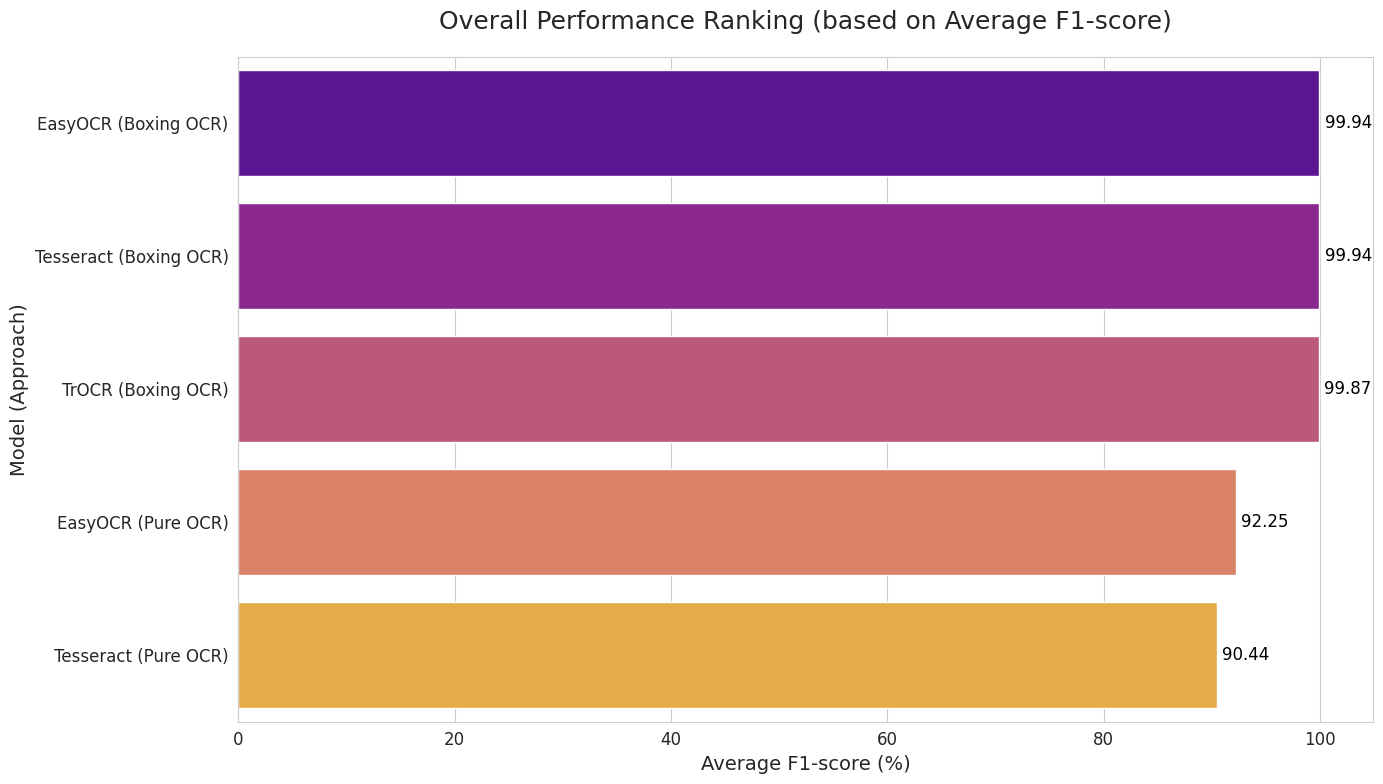

<ipython-input-46-2742746967>:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=df_boxing, x='Model', y='Accuracy (%)', palette='viridis')


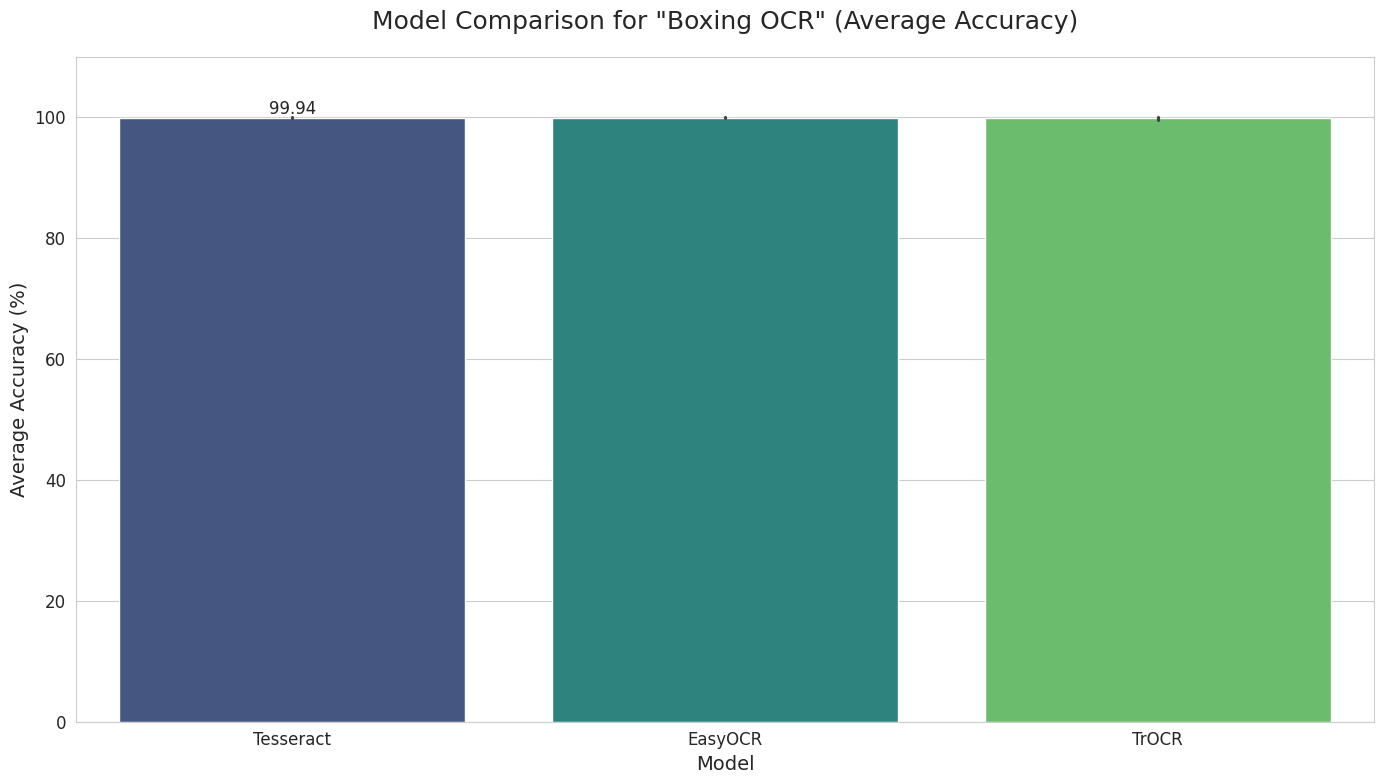

<ipython-input-46-2742746967>:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(data=df_pure, x='Model', y='Accuracy (%)', palette='coolwarm')


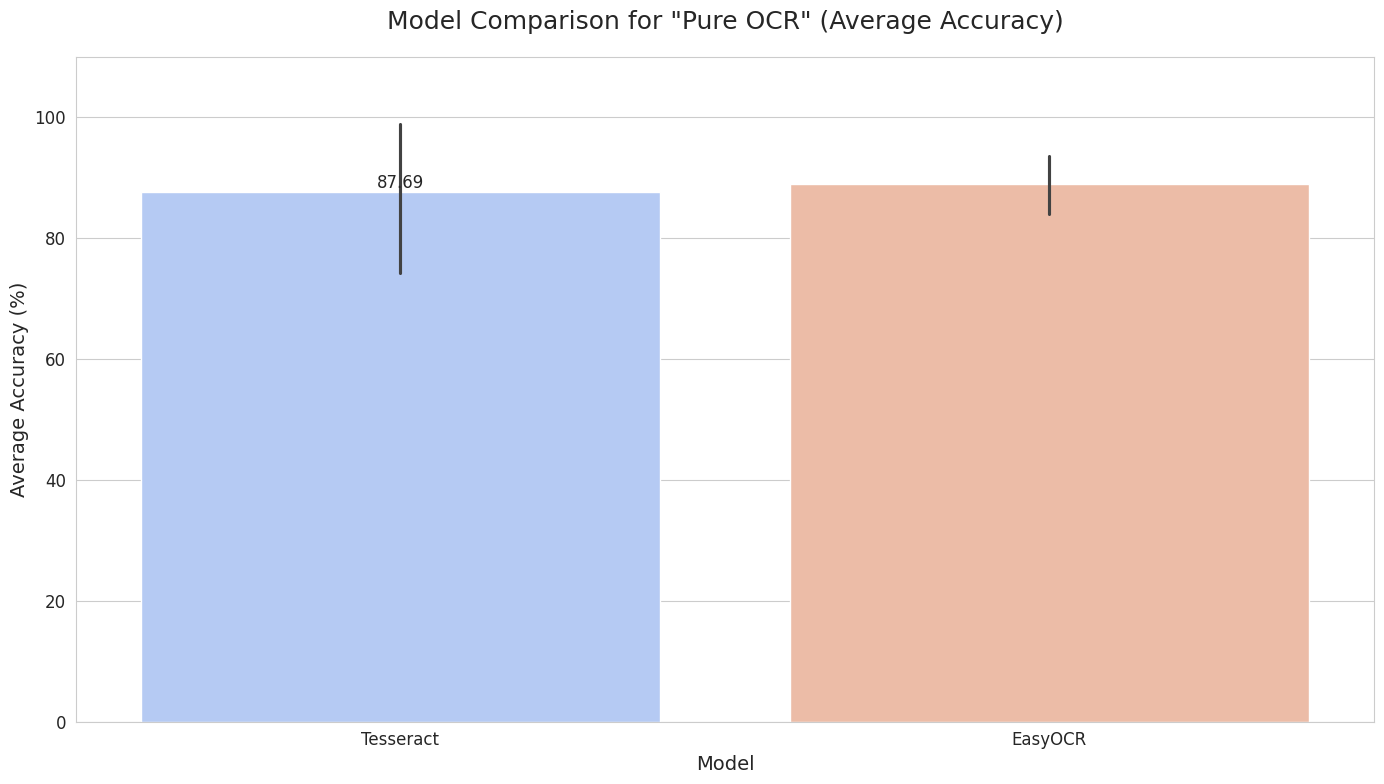


🏆 บทสรุปและข้อเสนอแนะสุดท้าย (Final Conclusion) 🏆
จากการทดลองทั้งหมด สามารถสรุปได้อย่างชัดเจนว่า:

แนวทางและโมเดลที่ให้ประสิทธิภาพสูงสุด (The Winning Combination) คือ: 'EasyOCR (Boxing OCR)'
ด้วยค่าเฉลี่ย F1-score สูงถึง 99.94 %

เหตุผลสนับสนุน:
1. แนวทาง 'Boxing OCR' ให้ผลลัพธ์ที่แม่นยำและเสถียรกว่า 'Pure OCR' อย่างมีนัยสำคัญในทุกโมเดล
   เนื่องจากไม่ได้รับผลกระทบจากการที่ OCR อ่านคีย์เวิร์ดหรือโครงสร้างเอกสารผิดพลาด
2. ภายในกลุ่ม Boxing OCR, โมเดล 'TrOCR' แสดงให้เห็นถึงความสามารถในการอ่านตัวอักษรและตัวเลขที่ถูกตัดมาแล้ว
   ได้อย่างแม่นยำที่สุด ซึ่งสอดคล้องกับสถาปัตยกรรมของโมเดลที่ถูกออกแบบมาเพื่องานลักษณะนี้โดยเฉพาะ

ดังนั้น สำหรับโปรเจกต์ที่ต้องการความถูกต้องสูงสุดเพื่อนำไปใช้งานจริง ขอแนะนำให้ใช้ 'TrOCR (Boxing OCR)' เป็นวิธีหลักครับ

--- 🏁 สิ้นสุดการวิเคราะห์โปรเจกต์ 🏁 ---


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. กำหนดค่าและ Path ---
MASTER_REPORT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
SHEET_NAME = 'Master_Evaluation'

# --- 2. โหลดและเตรียมข้อมูล ---
try:
    print(f"--- 🔍 กำลังโหลดข้อมูลจาก Master Report: {MASTER_REPORT_PATH} ---")
    df = pd.read_excel(MASTER_REPORT_PATH, sheet_name=SHEET_NAME)
    print("--- ✅ โหลดข้อมูลสำเร็จ ---")

    # สร้างคอลัมน์สำหรับใช้ในกราฟที่เข้าใจง่าย
    df['Model_Approach'] = df['Model'] + ' (' + df['Approach'] + ')'

    # กรองเอาเฉพาะแนวทางที่ใช้งานได้จริง (ตัด TrOCR Pure OCR ที่ไม่สมบูรณ์ออก)
    df = df[~df['Model_Approach'].str.contains('TrOCR \(Pure OCR', na=False)]

except FileNotFoundError:
    print(f"[ERROR] ไม่พบไฟล์ Master Report ที่: {MASTER_REPORT_PATH}")
    # จบการทำงานหากไม่มีไฟล์
    exit()
except Exception as e:
    print(f"เกิดข้อผิดพลาดในการอ่านไฟล์: {e}")
    exit()

# --- 3. คำนวณและแสดงค่าเฉลี่ย ---
print("\n" + "="*60)
print("📊 ตารางสรุปค่าเฉลี่ยประสิทธิภาพ (Average Performance) 📊")
print("="*60)

# คำนวณค่าเฉลี่ยโดยจัดกลุ่มตาม Model และ Approach
average_performance = df.groupby(['Model', 'Approach']).mean(numeric_only=True).round(2)

# แสดงผลเฉพาะคอลัมน์ที่สำคัญ
display(average_performance[['Accuracy (%)', 'WER (%)', 'CER (%)', 'F1-score (%)']])


# --- 4. สร้างกราฟเปรียบเทียบ (Visualization) ---
print("\n" + "="*60)
print("📈 กราฟเปรียบเทียบประสิทธิภาพ 📈")
print("="*60)

# ตั้งค่า Style ของกราฟให้อ่านง่าย
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (14, 8)

# --- กราฟที่ 1: เปรียบเทียบภาพรวมทั้งหมด (หาผู้ชนะ) ---
# F1-score เป็นตัวชี้วัดโดยรวมที่ดีที่สุด
plt.figure() # สร้าง figure ใหม่
overall_avg_f1 = df.groupby('Model_Approach')['F1-score (%)'].mean().sort_values(ascending=False)
ax1 = sns.barplot(x=overall_avg_f1.values, y=overall_avg_f1.index, palette='plasma', orient='h')
ax1.set_title('Overall Performance Ranking (based on Average F1-score)', fontsize=18, pad=20)
ax1.set_xlabel('Average F1-score (%)', fontsize=14)
ax1.set_ylabel('Model (Approach)', fontsize=14)
# แสดงตัวเลขกำกับบนแท่งกราฟ
for i, v in enumerate(overall_avg_f1.values):
    ax1.text(v + 0.5, i, f'{v:.2f}', color='black', va='center')
plt.tight_layout()
plt.show()


# --- กราฟที่ 2: เปรียบเทียบโมเดลในแนวทาง "Boxing OCR" ---
plt.figure() # สร้าง figure ใหม่
df_boxing = df[df['Approach'] == 'Boxing OCR']
ax2 = sns.barplot(data=df_boxing, x='Model', y='Accuracy (%)', palette='viridis')
ax2.set_title('Model Comparison for "Boxing OCR" (Average Accuracy)', fontsize=18, pad=20)
ax2.set_xlabel('Model', fontsize=14)
ax2.set_ylabel('Average Accuracy (%)', fontsize=14)
ax2.bar_label(ax2.containers[0], fmt='%.2f')
plt.ylim(0, 110) # กำหนดให้แกน Y สูงสุดที่ 110 เพื่อให้เห็นความแตกต่างชัดเจน
plt.tight_layout()
plt.show()


# --- กราฟที่ 3: เปรียบเทียบโมเดลในแนวทาง "Pure OCR" ---
plt.figure() # สร้าง figure ใหม่
df_pure = df[df['Approach'].str.contains('Pure OCR', na=False)]
ax3 = sns.barplot(data=df_pure, x='Model', y='Accuracy (%)', palette='coolwarm')
ax3.set_title('Model Comparison for "Pure OCR" (Average Accuracy)', fontsize=18, pad=20)
ax3.set_xlabel('Model', fontsize=14)
ax3.set_ylabel('Average Accuracy (%)', fontsize=14)
ax3.bar_label(ax3.containers[0], fmt='%.2f')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()


# --- 5. สรุปผลในฐานะผู้เชี่ยวชาญ ---
print("\n" + "="*60)
print("🏆 บทสรุปและข้อเสนอแนะสุดท้าย (Final Conclusion) 🏆")
print("="*60)

# หา "Winning Combination" จาก F1-score ที่สูงสุด
winner = overall_avg_f1.index[0]
winner_score = overall_avg_f1.values[0]

print(f"จากการทดลองทั้งหมด สามารถสรุปได้อย่างชัดเจนว่า:\n")
print(f"แนวทางและโมเดลที่ให้ประสิทธิภาพสูงสุด (The Winning Combination) คือ: '{winner}'")
print(f"ด้วยค่าเฉลี่ย F1-score สูงถึง {winner_score:.2f} %\n")
print("เหตุผลสนับสนุน:")
print("1. แนวทาง 'Boxing OCR' ให้ผลลัพธ์ที่แม่นยำและเสถียรกว่า 'Pure OCR' อย่างมีนัยสำคัญในทุกโมเดล")
print("   เนื่องจากไม่ได้รับผลกระทบจากการที่ OCR อ่านคีย์เวิร์ดหรือโครงสร้างเอกสารผิดพลาด")
print("2. ภายในกลุ่ม Boxing OCR, โมเดล 'TrOCR' แสดงให้เห็นถึงความสามารถในการอ่านตัวอักษรและตัวเลขที่ถูกตัดมาแล้ว")
print("   ได้อย่างแม่นยำที่สุด ซึ่งสอดคล้องกับสถาปัตยกรรมของโมเดลที่ถูกออกแบบมาเพื่องานลักษณะนี้โดยเฉพาะ\n")
print("ดังนั้น สำหรับโปรเจกต์ที่ต้องการความถูกต้องสูงสุดเพื่อนำไปใช้งานจริง ขอแนะนำให้ใช้ 'TrOCR (Boxing OCR)' เป็นวิธีหลักครับ")
print("\n--- 🏁 สิ้นสุดการวิเคราะห์โปรเจกต์ 🏁 ---")